# Ruelle-Bowen CTMC Maximum Entropy Verification on 2D Periodic Lattice

This notebook verifies the theoretical results from "Ruelle-Bowen continuous-time random walk" paper:

1. **Maximum entropy rate equals maximum eigenvalue**: The differential entropy rate $h_\eta(Q)$ achieves its maximum at $Q^{RB}$, and $h_1(Q^{RB}) = \lambda_A$ (the maximum eigenvalue of the adjacency matrix)

2. **Equiprobability of trajectories**: All trajectories with the same number of jumps N between nodes i and j have equal probability $\hat{\phi}_i \phi_j / \lambda_A^N$

3. **Exponential waiting times**: Waiting times are exponentially distributed with parameter $\lambda_A$, independent of the current state

We test these predictions on a 2D periodic lattice.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import eigs
from scipy.stats import expon, kstest, chi2_contingency
from collections import defaultdict, Counter
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Build 2D Periodic Lattice (Torus) and Compute Eigenvalues

In [ ]:
class PeriodicLattice2D:
    """2D lattice with periodic boundary conditions (no self-loops)"""

    def __init__(self, Lx, Ly):
        self.Lx = Lx
        self.Ly = Ly
        self.N = Lx * Ly
        self.adjacency = self._build_adjacency_matrix()
        self.lambda_A, self.phi, self.phi_hat = self._compute_frobenius_perron()

    def _node_to_coords(self, node):
        """Convert node index to (x, y) coordinates"""
        return (node // self.Ly, node % self.Ly)

    def _coords_to_node(self, x, y):
        """Convert (x, y) coordinates to node index with periodic boundary"""
        return (x % self.Lx) * self.Ly + (y % self.Ly)

    def _build_adjacency_matrix(self):
        """Build adjacency matrix for 2D periodic lattice """
        A = lil_matrix((self.N, self.N), dtype=float)

        for node in range(self.N):
            x, y = self._node_to_coords(node)
            neighbors = [
                self._coords_to_node(x+1, y),  # right
                self._coords_to_node(x-1, y),  # left
                self._coords_to_node(x, y+1),  # up
                self._coords_to_node(x, y-1),  # down
            ]
            for neighbor in neighbors:
                A[node, neighbor] = 1.0

        return A.tocsr()

    def get_neighbors(self, node):
        """Get list of neighbors for a given node"""
        x, y = self._node_to_coords(node)
        return [
            self._coords_to_node(x+1, y),
            self._coords_to_node(x-1, y),
            self._coords_to_node(x, y+1),
            self._coords_to_node(x, y-1),
        ]

    def _compute_frobenius_perron(self):
        """Compute Frobenius-Perron eigenvalue and eigenvectors"""
        # For regular lattice, we know lambda_A = degree = 4
        # But let's compute it to verify

        # Compute ALL eigenvalues to find the actual maximum
        A_dense = self.adjacency.toarray()
        eigenvalues_all = np.linalg.eigvals(A_dense)
        lambda_A = np.max(np.real(eigenvalues_all))

        # Now get the corresponding eigenvector
        eigenvalues, eigenvectors = eigs(self.adjacency, k=1, sigma=lambda_A, which='LM')
        phi = np.real(eigenvectors[:, 0])
        phi = np.abs(phi)  # Ensure positive

        # For symmetric regular lattice, left = right eigenvector
        phi_hat = phi.copy()

        # Normalize so <phi, phi_hat> = 1
        normalization = np.dot(phi, phi_hat)
        phi_hat = phi_hat / normalization

        return lambda_A, phi, phi_hat

    def get_stationary_distribution(self):
        """Return π^RB = φ ⊙ φ̂ (element-wise product)"""
        return self.phi * self.phi_hat

# Create lattice
Lx, Ly = 6, 6  # 6x6 lattice = 36 nodes (manageable for analysis)
lattice = PeriodicLattice2D(Lx, Ly)

print(f"Lattice size: {Lx} × {Ly} = {lattice.N} nodes")
print(f"Maximum eigenvalue λ_A: {lattice.lambda_A:.6f}")
print(f"Analytical value (degree): 4.0")
print(f"\nStationary distribution π^RB:")
pi_RB = lattice.get_stationary_distribution()
print(f"  Sum: {np.sum(pi_RB):.6f} (should be 1.0)")
print(f"  Uniform? {np.allclose(pi_RB, 1/lattice.N)}")
print(f"  Min: {np.min(pi_RB):.6f}, Max: {np.max(pi_RB):.6f}")

Lattice size: 6 × 6 = 36 nodes
Maximum eigenvalue λ_A: 4.000000
Analytical value (degree): 4.0

Stationary distribution π^RB:
  Sum: 1.000000 (should be 1.0)
  Uniform? True
  Min: 0.027778, Max: 0.027778


## 2. Continuous-Time Ruelle-Bowen Random Walk with Gillespie Algorithm

In [ ]:
class RuelleBowenCTMC:
    """Continuous-time Ruelle-Bowen random walk

    From the paper:
    - Q^RB_{ij} = a_{ij} * φ_j / φ_i  for i ≠ j (off-diagonal)
    - Q^RB_{ii} = -λ_A  (diagonal, ensures row sum = 0)

    Key property: All waiting times are exp(λ_A), independent of state!
    """

    def __init__(self, lattice):
        self.lattice = lattice
        self.N = lattice.N
        self.lambda_A = lattice.lambda_A
        self.phi = lattice.phi
        self.phi_hat = lattice.phi_hat
        self.pi_RB = lattice.get_stationary_distribution()

        # Build Q^RB generator matrix
        self.Q_RB = self._build_generator()

    def _build_generator(self):
        """Build Q^RB generator matrix

        Formula from paper:
        Q^RB = diag(φ)^{-1} A diag(φ) - λ_A I

        Equivalently:
        - Off-diagonal: q_ij^RB = a_ij * φ_j / φ_i (for i ≠ j)
        - Diagonal: q_ii^RB = -λ_A (ensures row sum = 0)

        This ensures:
        1. Q^RB 1 = 0 (row sums are zero)
        2. (Q^RB)^T π^RB = 0 (π^RB is stationary)
        3. Exit rate from each node is λ_A
        """
        A = self.lattice.adjacency.toarray()
        Q_RB = np.zeros((self.N, self.N))

        for i in range(self.N):
            for j in range(self.N):
                if i != j and A[i, j] > 0:
                    Q_RB[i, j] = A[i, j] * self.phi[j] / self.phi[i]
            Q_RB[i, i] = -np.sum(Q_RB[i, :])

        return Q_RB

    def gillespie_step(self, current_node):
        """
        Perform one Gillespie step for RB-CTMC

        Key insight from paper:
        - Waiting time has rate q_i = λ_A (INDEPENDENT of current state i!)
        - Transition probability π_ij = q_ij / q_i ∝ φ_j

        Returns:
            next_node: next state
            waiting_time: exponentially distributed with rate λ_A
        """
        exit_rate = -self.Q_RB[current_node, current_node]
        waiting_time = np.random.exponential(1.0 / exit_rate)

        neighbors = self.lattice.get_neighbors(current_node)
        transition_rates = np.array([self.Q_RB[current_node, j] for j in neighbors])
        probs = transition_rates / np.sum(transition_rates)
        next_node = np.random.choice(neighbors, p=probs)

        return next_node, waiting_time

    def generate_trajectory(self, T, initial_node=None):
        """
        Generate a trajectory using Gillespie algorithm up to time T

        Args:
            T: total duration of the trajectory (physical time)
            initial_node: starting node (if None, sampled from pi_RB)

        Returns:
            trajectory: list of states visited
            waiting_times: list of waiting times at each state
            n_steps: number of transitions performed
        """
        if initial_node is None:
            initial_node = np.random.choice(self.N, p=self.pi_RB)

        current_node = initial_node
        trajectory = [current_node]
        waiting_times = []
        current_time = 0.0

        while True:
            next_node, waiting_time = self.gillespie_step(current_node)

            # Stop if adding this step would exceed T
            if current_time + waiting_time > T:
                break

            trajectory.append(next_node)
            waiting_times.append(waiting_time)
            current_time += waiting_time
            current_node = next_node

        return trajectory, waiting_times, len(waiting_times)


# Initialize RB-CTMC
rb_ctmc = RuelleBowenCTMC(lattice)

print("Ruelle-Bowen CTMC initialized")
print(f"\nQ^RB properties:")
print(f"  Row sums (should be ~0): max|sum| = {np.max(np.abs(rb_ctmc.Q_RB.sum(axis=1))):.2e}")
print(f"  (Q^RB)^T π^RB = 0? max|val| = {np.max(np.abs(rb_ctmc.Q_RB.T @ rb_ctmc.pi_RB)):.2e}")
print(f"\nDiagonal elements (exit rates):")
exit_rates = -np.diag(rb_ctmc.Q_RB)
print(f"  All equal to λ_A? {np.allclose(exit_rates, lattice.lambda_A)}")
print(f"  Min: {np.min(exit_rates):.6f}, Max: {np.max(exit_rates):.6f}")
print(f"  Expected (λ_A): {lattice.lambda_A:.6f}")

Ruelle-Bowen CTMC initialized

Q^RB properties:
  Row sums (should be ~0): max|sum| = 7.77e-16
  (Q^RB)^T π^RB = 0? max|val| = 2.43e-17

Diagonal elements (exit rates):
  All equal to λ_A? True
  Min: 4.000000, Max: 4.000000
  Expected (λ_A): 4.000000


## 3. Generate Ensemble of Trajectories

In [6]:
# Generate trajectories
n_trajectories = 10000
T_per_traj = 3500 / lattice.lambda_A  # equivalent expected duration to ~3000 steps

print(f"Generating {n_trajectories} trajectories with T = {T_per_traj:.4f} each...")

trajectories = []
all_waiting_times = []
waiting_times_per_traj = []
n_steps_list = []

for i in tqdm(range(n_trajectories)):
    traj, wait_times, n_steps = rb_ctmc.generate_trajectory(T_per_traj)
    trajectories.append(traj)
    waiting_times_per_traj.append(wait_times)
    all_waiting_times.extend(wait_times)
    n_steps_list.append(n_steps)

all_waiting_times = np.array(all_waiting_times)
n_steps_list = np.array(n_steps_list)

print(f"\nGeneration complete!")
print(f"Total transitions: {len(all_waiting_times):,}")
print(f"Mean steps per trajectory: {np.mean(n_steps_list):.1f} (expected ~500)")
print(f"Std steps per trajectory: {np.std(n_steps_list):.1f}")
print(f"Mean waiting time: {np.mean(all_waiting_times):.6f}")
print(f"Expected (1/λ_A): {1.0/lattice.lambda_A:.6f}")
print(f"Relative error: {abs(np.mean(all_waiting_times) - 1/lattice.lambda_A) / (1/lattice.lambda_A) * 100:.2f}%")

Generating 10000 trajectories with T = 875.0000 each...


100%|██████████| 10000/10000 [19:24<00:00,  8.59it/s]



Generation complete!
Total transitions: 35,002,644
Mean steps per trajectory: 3500.3 (expected ~500)
Std steps per trajectory: 59.0
Mean waiting time: 0.249910
Expected (1/λ_A): 0.250000
Relative error: 0.04%


In [8]:
import pickle
from google.colab import drive

# Monta Drive (se non è già montato)
drive.mount('/content/drive')

# Raccogli tutti i risultati
data_to_save = {
    'trajectories': trajectories,
    'waiting_times_per_traj': waiting_times_per_traj,
    'all_waiting_times': all_waiting_times,
    'n_steps_list': n_steps_list,
}

# Salva il file
save_path = '/content/drive/MyDrive/trajectories_3500.pkl'

with open(save_path, 'wb') as f:
    pickle.dump(data_to_save, f)

print(f"✅ Salvato con successo in: {save_path}")
print(f"   - Traiettorie: {len(trajectories)}")
print(f"   - Totale waiting times: {len(all_waiting_times):,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Salvato con successo in: /content/drive/MyDrive/trajectories_3500.pkl
   - Traiettorie: 10000
   - Totale waiting times: 35,002,644


In [9]:
from google.colab import drive
import pickle

drive.mount('/content/drive')

load_path = '/content/drive/MyDrive/trajectories_3500.pkl'
with open(load_path, 'rb') as f:
    data = pickle.load(f)

trajectories           = data['trajectories']
waiting_times_per_traj = data['waiting_times_per_traj']
all_waiting_times      = data['all_waiting_times']
n_steps_list           = data['n_steps_list']

print(f'✓ Caricato da: {load_path}')
print(f'  Traiettorie        : {len(trajectories):,}')
print(f'  Waiting times totali: {len(all_waiting_times):,}')
print(f'  Steps medi         : {n_steps_list.mean():.1f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Caricato da: /content/drive/MyDrive/trajectories_3500.pkl
  Traiettorie        : 10,000
  Waiting times totali: 35,002,644
  Steps medi         : 3500.3


## Genero traiettorie con T=500/$\lambda$

In [15]:
# Generate trajectories
n_trajectories = 10000
T_per_traj = 500 / lattice.lambda_A  # equivalent expected duration to ~3000 steps

print(f"Generating {n_trajectories} trajectories with T = {T_per_traj:.4f} each...")

trajectories = []
all_waiting_times = []
waiting_times_per_traj = []
n_steps_list = []

for i in tqdm(range(n_trajectories)):
    traj, wait_times, n_steps = rb_ctmc.generate_trajectory(T_per_traj)
    trajectories.append(traj)
    waiting_times_per_traj.append(wait_times)
    all_waiting_times.extend(wait_times)
    n_steps_list.append(n_steps)

all_waiting_times = np.array(all_waiting_times)
n_steps_list = np.array(n_steps_list)

print(f"\nGeneration complete!")
print(f"Total transitions: {len(all_waiting_times):,}")
print(f"Mean steps per trajectory: {np.mean(n_steps_list):.1f} (expected ~500)")
print(f"Std steps per trajectory: {np.std(n_steps_list):.1f}")
print(f"Mean waiting time: {np.mean(all_waiting_times):.6f}")
print(f"Expected (1/λ_A): {1.0/lattice.lambda_A:.6f}")
print(f"Relative error: {abs(np.mean(all_waiting_times) - 1/lattice.lambda_A) / (1/lattice.lambda_A) * 100:.2f}%")

Generating 10000 trajectories with T = 125.0000 each...


100%|██████████| 10000/10000 [02:46<00:00, 59.98it/s]



Generation complete!
Total transitions: 5,002,564
Mean steps per trajectory: 500.3 (expected ~500)
Std steps per trajectory: 22.4
Mean waiting time: 0.249376
Expected (1/λ_A): 0.250000
Relative error: 0.25%


salvo traiettorie

In [16]:
import pickle
import os

# ── Salva su Drive ─────────────────────────────────────────────
save_dir  = '/content/drive/MyDrive/ruelle_bowen_results'
save_path = os.path.join(save_dir, 'trajectories_T500.pkl')
os.makedirs(save_dir, exist_ok=True)

payload = {
    'trajectories':           trajectories,
    'waiting_times_per_traj': waiting_times_per_traj,
    'all_waiting_times':      all_waiting_times,
    'n_steps_list':           n_steps_list,
    'n_trajectories':         n_trajectories,
    'T_per_traj':             T_per_traj,
    'T_nominal':              500,
    'lambda_A':               lattice.lambda_A,
}

with open(save_path, 'wb') as f:
    pickle.dump(payload, f)

print(f"✓ Salvato in '{save_path}'")
print(f"  Traiettorie : {n_trajectories:,}")
print(f"  T nominale  : 500  →  T effettivo = {T_per_traj:.4f}")

✓ Salvato in '/content/drive/MyDrive/ruelle_bowen_results/trajectories_T500.pkl'
  Traiettorie : 10,000
  T nominale  : 500  →  T effettivo = 125.0000


In [19]:
from google.colab import drive
import pickle

drive.mount('/content/drive')

load_path = '/content/drive/MyDrive/ruelle_bowen_results/trajectories_T500.pkl'
with open(load_path, 'rb') as f:
    data = pickle.load(f)

trajectories           = data['trajectories']
waiting_times_per_traj = data['waiting_times_per_traj']
all_waiting_times      = data['all_waiting_times']
n_steps_list           = data['n_steps_list']

print(f'✓ Caricato da: {load_path}')
print(f'  Traiettorie        : {len(trajectories):,}')
print(f'  Waiting times totali: {len(all_waiting_times):,}')
print(f'  Steps medi         : {n_steps_list.mean():.1f}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Caricato da: /content/drive/MyDrive/ruelle_bowen_results/trajectories_T500.pkl
  Traiettorie        : 10,000
  Waiting times totali: 5,002,564
  Steps medi         : 500.3


# Calcolo entropy rate con metodo 1 & 2 e visualizzazioni per T=500/$\lambda$

In [22]:
import pickle
import numpy as np
from collections import defaultdict

# ── Carica pkl ────────────────────────────────────────────────
load_path = '/content/drive/MyDrive/ruelle_bowen_results/trajectories_T500.pkl'
with open(load_path, 'rb') as f:
    data = pickle.load(f)

trajectories           = data['trajectories']
waiting_times_per_traj = data['waiting_times_per_traj']
all_waiting_times      = data['all_waiting_times']
n_steps_list           = data['n_steps_list']
n_trajectories         = data['n_trajectories']
T_per_traj             = data['T_per_traj']

print(f"✓ Caricate {n_trajectories:,} traiettorie da '{load_path}'")
print(f"  T nominale : 500  →  T effettivo = {T_per_traj:.4f}")

# ── Funzioni ──────────────────────────────────────────────────
def compute_differential_entropy_rate_theoretical(Q, pi):
    h = 0.0
    n = len(pi)
    for i in range(n):
        h += -pi[i] * Q[i, i]
        for j in range(n):
            if i != j and Q[i, j] > 0:
                h += -pi[i] * Q[i, j] * np.log(Q[i, j])
    return h

def compute_entropy_rate_from_trajectories(trajectories, waiting_times_list, lattice):
    transition_counts    = defaultdict(int)
    total_time_per_state = defaultdict(float)

    for traj_idx, traj in enumerate(trajectories):
        wait_times = waiting_times_list[traj_idx]
        for k in range(len(traj) - 1):
            i, j = traj[k], traj[k+1]
            transition_counts[(i, j)] += 1
            total_time_per_state[i]   += wait_times[k]

    estimated_rates = {}
    for (i, j), count in transition_counts.items():
        if total_time_per_state[i] > 0:
            estimated_rates[(i, j)] = count / total_time_per_state[i]

    total_time   = sum(total_time_per_state.values())
    pi_empirical = {i: t / total_time for i, t in total_time_per_state.items()}

    h_empirical = 0.0
    for i in range(lattice.N):
        if i not in pi_empirical:
            continue
        q_i = sum(estimated_rates.get((i, j), 0) for j in range(lattice.N) if j != i)
        h_empirical += pi_empirical[i] * q_i
        for j in range(lattice.N):
            if (i, j) in estimated_rates and estimated_rates[(i, j)] > 0:
                q_ij = estimated_rates[(i, j)]
                h_empirical += -pi_empirical[i] * q_ij * np.log(q_ij)

    return h_empirical

# ── Calcoli ───────────────────────────────────────────────────
h_theoretical = compute_differential_entropy_rate_theoretical(rb_ctmc.Q_RB, rb_ctmc.pi_RB)

print("\n" + "=" * 60)
print("ENTROPY RATE VERIFICATION")
print("=" * 60)
print(f"\nSource: '{load_path}'  ({n_trajectories:,} traiettorie)")
print(f"\nTheoretical h_1(Q^RB): {h_theoretical:.6f}")
print(f"Expected (λ_A):        {lattice.lambda_A:.6f}")
print(f"Match? {np.isclose(h_theoretical, lattice.lambda_A, rtol=1e-5)}")
print(f"Relative error: {abs(h_theoretical - lattice.lambda_A) / lattice.lambda_A * 100:.6f}%")

print(f"\nComputing empirical entropy rate from {n_trajectories:,} trajectories...")
h_empirical = compute_entropy_rate_from_trajectories(trajectories, waiting_times_per_traj, lattice)

print(f"\nEmpirical h(trajectories): {h_empirical:.6f}")
print(f"Theoretical h_1(Q^RB):     {h_theoretical:.6f}")
print(f"Relative error: {abs(h_empirical - h_theoretical) / h_theoretical * 100:.6f}%")

✓ Caricate 10,000 traiettorie da '/content/drive/MyDrive/ruelle_bowen_results/trajectories_T500.pkl'
  T nominale : 500  →  T effettivo = 125.0000

ENTROPY RATE VERIFICATION

Source: '/content/drive/MyDrive/ruelle_bowen_results/trajectories_T500.pkl'  (10,000 traiettorie)

Theoretical h_1(Q^RB): 4.000000
Expected (λ_A):        4.000000
Match? True
Relative error: 0.000000%

Computing empirical entropy rate from 10,000 trajectories...

Empirical h(trajectories): 3.999941
Theoretical h_1(Q^RB):     4.000000
Relative error: 0.001484%


In [21]:
import pickle
import numpy as np
from collections import defaultdict

# ── Carica pkl ────────────────────────────────────────────────
load_path = '/content/drive/MyDrive/ruelle_bowen_results/trajectories_T500.pkl'
with open(load_path, 'rb') as f:
    data = pickle.load(f)

trajectories           = data['trajectories']
waiting_times_per_traj = data['waiting_times_per_traj']
n_trajectories         = data['n_trajectories']
T_per_traj             = data['T_per_traj']

print(f"✓ Caricate {n_trajectories:,} traiettorie da '{load_path}'")
print(f"  T nominale : 500  →  T effettivo = {T_per_traj:.4f}")

# ── Funzione ──────────────────────────────────────────────────
def compute_entropy_rate_path_prob_empirical(trajectories, waiting_times_list, lattice):
    transition_counts    = defaultdict(int)
    total_time_per_state = defaultdict(float)

    for traj, wait_times in zip(trajectories, waiting_times_list):
        for k in range(len(traj) - 1):
            i, j = traj[k], traj[k+1]
            transition_counts[(i, j)] += 1
            total_time_per_state[i]   += wait_times[k]

    q_hat = {}
    for (i, j), n in transition_counts.items():
        q_hat[(i, j)] = n / total_time_per_state[i]

    q_hat_exit = defaultdict(float)
    for (i, j), rate in q_hat.items():
        q_hat_exit[i] += rate

    T_tot  = sum(total_time_per_state.values())
    pi_hat = {i: t / T_tot for i, t in total_time_per_state.items()}

    log_probs = []
    durations = []

    for traj, wait_times in zip(trajectories, waiting_times_list):
        x0 = traj[0]
        if x0 not in pi_hat or pi_hat[x0] == 0:
            continue

        log_p = np.log(pi_hat[x0])

        for k in range(len(traj) - 1):
            i, j = traj[k], traj[k+1]
            tau   = wait_times[k]
            if (i, j) not in q_hat or q_hat[(i, j)] == 0:
                continue
            log_p += np.log(q_hat[(i, j)])
            log_p -= q_hat_exit[i] * tau

        log_probs.append(log_p)
        durations.append(sum(wait_times))

    return -np.mean([lp / T for lp, T in zip(log_probs, durations)])

# ── Calcolo ───────────────────────────────────────────────────
print("\n" + "=" * 60)
print("ENTROPY RATE — METODO PATH PROBABILITY")
print("=" * 60)
print(f"\nSource: '{load_path}'  ({n_trajectories:,} traiettorie)")
print(f"\nComputing empirical entropy rate...")

h_empirical_two = compute_entropy_rate_path_prob_empirical(
    trajectories, waiting_times_per_traj, lattice
)

print(f"\nEmpirical h (path-prob) : {h_empirical_two:.6f}")
print(f"Theoretical h_1(Q^RB)   : {h_theoretical:.6f}")
print(f"Relative error          : {abs(h_empirical_two - h_theoretical) / h_theoretical * 100:.2f}%")

✓ Caricate 10,000 traiettorie da '/content/drive/MyDrive/ruelle_bowen_results/trajectories_T500.pkl'
  T nominale : 500  →  T effettivo = 125.0000

ENTROPY RATE — METODO PATH PROBABILITY

Source: '/content/drive/MyDrive/ruelle_bowen_results/trajectories_T500.pkl'  (10,000 traiettorie)

Computing empirical entropy rate...

Empirical h (path-prob) : 4.028666
Theoretical h_1(Q^RB)   : 4.000000
Relative error          : 0.72%


In [23]:
import pickle
import numpy as np
from collections import defaultdict

# ── Carica pkl ────────────────────────────────────────────────
load_path = '/content/drive/MyDrive/ruelle_bowen_results/trajectories_T500.pkl'
with open(load_path, 'rb') as f:
    data = pickle.load(f)

trajectories           = data['trajectories']
waiting_times_per_traj = data['waiting_times_per_traj']
n_trajectories         = data['n_trajectories']
T_per_traj             = data['T_per_traj']
h_theoretical          = data['lambda_A']  # λ_A salvato nel pkl

print(f"✓ Caricate {n_trajectories:,} traiettorie da '{load_path}'")
print(f"  T nominale : 500  →  T effettivo = {T_per_traj:.4f}")

# ── Helper ────────────────────────────────────────────────────
def _h_method1(trajs, waits, N):
    tc  = defaultdict(int)
    tts = defaultdict(float)
    for traj, wt in zip(trajs, waits):
        for k in range(len(traj) - 1):
            i, j = traj[k], traj[k+1]
            tc[(i, j)] += 1
            tts[i]     += wt[k]
    rates = {(i,j): cnt/tts[i] for (i,j), cnt in tc.items() if tts[i] > 0}
    T_tot = sum(tts.values())
    pi_e  = {i: t/T_tot for i, t in tts.items()}
    h = 0.0
    for i in range(N):
        if i not in pi_e: continue
        q_i = sum(rates.get((i,j), 0) for j in range(N) if j != i)
        h  += pi_e[i] * q_i
        for j in range(N):
            q_ij = rates.get((i,j), 0)
            if q_ij > 0:
                h -= pi_e[i] * q_ij * np.log(q_ij)
    return h


def _h_method2(trajs, waits):
    tc  = defaultdict(int)
    tts = defaultdict(float)
    for traj, wt in zip(trajs, waits):
        for k in range(len(traj) - 1):
            i, j = traj[k], traj[k+1]
            tc[(i, j)] += 1
            tts[i]     += wt[k]
    q_hat  = {(i,j): cnt/tts[i] for (i,j), cnt in tc.items() if tts[i] > 0}
    q_exit = defaultdict(float)
    for (i,j), r in q_hat.items():
        q_exit[i] += r
    T_tot  = sum(tts.values())
    pi_hat = {i: t/T_tot for i, t in tts.items()}
    lps, durs = [], []
    for traj, wt in zip(trajs, waits):
        x0 = traj[0]
        if pi_hat.get(x0, 0) == 0: continue
        lp = np.log(pi_hat[x0])
        for k in range(len(traj) - 1):
            i, j = traj[k], traj[k+1]
            q_ij = q_hat.get((i,j), 0)
            if q_ij == 0: continue
            lp += np.log(q_ij) - q_exit[i] * wt[k]
        lps.append(lp)
        durs.append(sum(wt))
    if not lps: return np.nan
    return -np.mean([lp/T for lp, T in zip(lps, durs)])


# ── Curve di convergenza ──────────────────────────────────────
n_checkpoints = 45
n_total       = len(trajectories)

idx_arr = np.unique(
    np.round(np.logspace(np.log10(20), np.log10(n_total), n_checkpoints)).astype(int)
)
idx_arr = np.clip(idx_arr, 1, n_total)

print(f"\nCalcolando convergenza su {len(idx_arr)} checkpoint "
      f"(fino a {n_total:,} traiettorie)…")

h1_curve, h2_curve, n_arr = [], [], []

for n in idx_arr:
    sub_t = trajectories[:n]
    sub_w = waiting_times_per_traj[:n]
    h1_curve.append(_h_method1(sub_t, sub_w, lattice.N))
    h2_curve.append(_h_method2(sub_t, sub_w))
    n_arr.append(n)

h1_curve = np.array(h1_curve)
h2_curve = np.array(h2_curve)
n_arr    = np.array(n_arr)
err1     = np.abs(h1_curve - h_theoretical) / h_theoretical * 100
err2     = np.abs(h2_curve - h_theoretical) / h_theoretical * 100

print(f"\n✓ Convergenza calcolata.")
print(f"  Metodo 1 finale : {h1_curve[-1]:.6f}  (err {err1[-1]:.3f}%)")
print(f"  Metodo 2 finale : {h2_curve[-1]:.6f}  (err {err2[-1]:.3f}%)")
print(f"  Teorico         : {h_theoretical:.6f}")

✓ Caricate 10,000 traiettorie da '/content/drive/MyDrive/ruelle_bowen_results/trajectories_T500.pkl'
  T nominale : 500  →  T effettivo = 125.0000

Calcolando convergenza su 45 checkpoint (fino a 10,000 traiettorie)…

✓ Convergenza calcolata.
  Metodo 1 finale : 3.999941  (err 0.001%)
  Metodo 2 finale : 4.028666  (err 0.717%)
  Teorico         : 4.000000


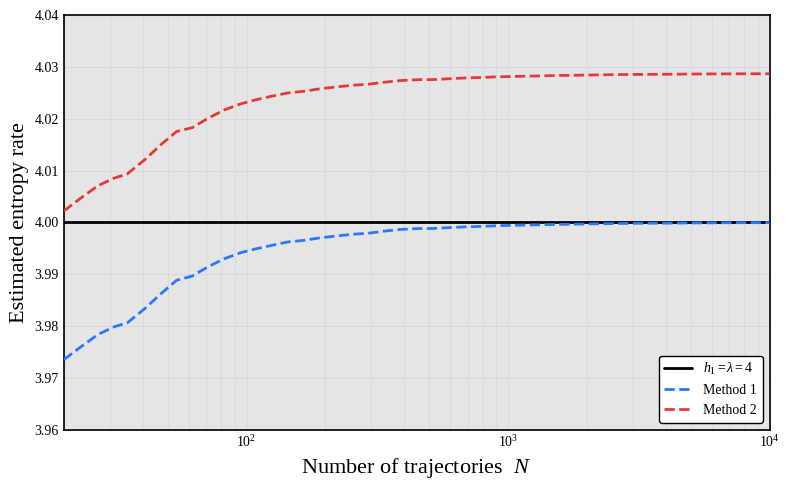

In [28]:
import matplotlib.pyplot as plt

# ── Palette e stile ────────────────────────────────────────────
C_TH  = "#000000"
C_M1  = "#2979FF"
C_M2  = "#E53935"
BG    = "white"
GRID  = "#DDDDDD"
plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Liberation Serif"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Liberation Serif",
    "mathtext.it": "Liberation Serif:italic",
    "mathtext.bf": "Liberation Serif:bold",
})

LABEL_KW  = dict(fontsize=16, fontfamily="Liberation Serif", color="black")
LEGEND_KW = dict(fontsize=10, facecolor="white", edgecolor="black",
                 labelcolor="black", prop={"family": "Liberation Serif"},
                 framealpha=1.0, frameon=True)

# ── Figura 1 — Convergenza principale ─────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5), facecolor=BG)
ax1.set_facecolor(BG)
for spine in ax1.spines.values():
    spine.set_edgecolor("black"); spine.set_linewidth(1.2)

ax1.fill_between(n_arr, h_theoretical*0.99, h_theoretical*1.01,
                 alpha=0.10, color=C_TH, zorder=1)
ax1.axhline(h_theoretical, color=C_TH, lw=2, linestyle='-', zorder=2,
            label=f'$h_1 = \\lambda = 4$')
ax1.plot(n_arr, h1_curve, color=C_M1, lw=2.0, zorder=3, linestyle='--',
         label='Method 1')
ax1.plot(n_arr, h2_curve, color=C_M2, lw=2.0, zorder=3, linestyle='--',
         label='Method 2')

ax1.set_xscale('log')
ax1.set_xlabel('Number of trajectories  $N$', **LABEL_KW)
ax1.set_ylabel('Estimated entropy rate', **LABEL_KW)
ax1.legend(**LEGEND_KW, loc='lower right')
ax1.grid(True, which='both', alpha=0.4)
ax1.tick_params(colors='black')

ax1.margins(0)
ax1.set_xlim(n_arr[0], n_arr[-1])

plt.tight_layout()
plt.savefig('fig1_convergenza.pdf', dpi=150, bbox_inches='tight', facecolor=BG, pad_inches=0.05)
plt.savefig('fig1_convergenza.png', dpi=150, bbox_inches='tight', facecolor=BG, pad_inches=0.05)
plt.show()



# Calcolo entropy rate con metodo 1 & 2 T=3500/$\lambda$

## 4. Verification 1: Entropy Rate Calculation

The differential entropy rate is defined as:
$$h_1(Q) = -\sum_i \pi_i q_{ii} - \sum_{i \neq j} \pi_i q_{ij} \log q_{ij}$$

For the RB-CTMC, the paper proves that $h_1(Q^{RB}) = \lambda_A$.

In [10]:
def compute_differential_entropy_rate_theoretical(Q, pi):
    h = 0.0
    n = len(pi)
    for i in range(n):
        h += -pi[i] * Q[i, i]
        for j in range(n):
            if i != j and Q[i, j] > 0:
                h += -pi[i] * Q[i, j] * np.log(Q[i, j])
    return h

def compute_entropy_rate_from_trajectories(trajectories, waiting_times_list, lattice):
    transition_counts    = defaultdict(int)
    total_time_per_state = defaultdict(float)

    for traj_idx, traj in enumerate(trajectories):
        wait_times = waiting_times_list[traj_idx]
        for k in range(len(traj) - 1):
            i, j = traj[k], traj[k+1]
            transition_counts[(i, j)] += 1
            total_time_per_state[i]   += wait_times[k]

    estimated_rates = {}
    for (i, j), count in transition_counts.items():
        if total_time_per_state[i] > 0:
            estimated_rates[(i, j)] = count / total_time_per_state[i]

    total_time   = sum(total_time_per_state.values())
    pi_empirical = {i: t / total_time for i, t in total_time_per_state.items()}

    h_empirical = 0.0
    for i in range(lattice.N):
        if i not in pi_empirical:
            continue
        q_i = sum(estimated_rates.get((i, j), 0) for j in range(lattice.N) if j != i)
        h_empirical += pi_empirical[i] * q_i
        for j in range(lattice.N):
            if (i, j) in estimated_rates and estimated_rates[(i, j)] > 0:
                q_ij = estimated_rates[(i, j)]
                h_empirical += -pi_empirical[i] * q_ij * np.log(q_ij)

    return h_empirical

# ── Usa le traiettorie caricate dal pkl ───────────────────────
n_trajectories = len(trajectories)

# Theoretical
h_theoretical = compute_differential_entropy_rate_theoretical(rb_ctmc.Q_RB, rb_ctmc.pi_RB)

print("=" * 60)
print("ENTROPY RATE VERIFICATION")
print("=" * 60)
print(f"\nSource: '{load_path}'  ({n_trajectories:,} traiettorie)")
print(f"\nTheoretical h_1(Q^RB): {h_theoretical:.6f}")
print(f"Expected (λ_A):        {lattice.lambda_A:.6f}")
print(f"Match? {np.isclose(h_theoretical, lattice.lambda_A, rtol=1e-5)}")
print(f"Relative error: {abs(h_theoretical - lattice.lambda_A) / lattice.lambda_A * 100:.6f}%")

# Empirical
print(f"\nComputing empirical entropy rate from {n_trajectories:,} trajectories...")
h_empirical = compute_entropy_rate_from_trajectories(trajectories, waiting_times_per_traj, lattice)

print(f"\nEmpirical h(trajectories): {h_empirical:.6f}")
print(f"Theoretical h_1(Q^RB):     {h_theoretical:.6f}")
print(f"Relative error: {abs(h_empirical - h_theoretical) / h_theoretical * 100:.7f}%")

ENTROPY RATE VERIFICATION

Source: '/content/drive/MyDrive/trajectories_3500.pkl'  (10,000 traiettorie)

Theoretical h_1(Q^RB): 4.000000
Expected (λ_A):        4.000000
Match? True
Relative error: 0.000000%

Computing empirical entropy rate from 10,000 trajectories...

Empirical h(trajectories): 3.999993
Theoretical h_1(Q^RB):     4.000000
Relative error: 0.0001855%




## Metodo 2 — Entropy Rate via Log-Probabilità di Traiettoria

Questa cella implementa un secondo stimatore empirico dell'entropy rate, alternativo al metodo
basato sui rate stimati. Invece di usare la formula stazionaria aggregata, qui si parte dalla
**definizione diretta** di entropy rate come:

$$h = -\lim_{T \to \infty} \frac{1}{T} \,\mathbb{E}[\log P(\omega)]$$

cioè si calcola letteralmente quanto è "sorprendente" ogni traiettoria in media per unità di tempo.

**Il calcolo avviene in tre passi:**

**1. Stima empirica di Q̂ e π̂**
Dalle traiettorie simulate si contano le transizioni osservate $n_{ij}$ e il tempo totale
trascorso in ogni stato $T_i$. Da questi si ricavano gli stimatori MLE standard:

$$\hat{q}_{ij} = \frac{n_{ij}}{T_i}, \qquad \hat{q}_i = \sum_{j \neq i} \hat{q}_{ij},
\qquad \hat{\pi}_i = \frac{T_i}{T_{\text{tot}}}$$

**2. Calcolo del log-likelihood di ogni traiettoria**
Per una CTMC, la probabilità di una traiettoria $\omega = (x_0, \tau_0, x_1, \tau_1, \ldots)$ è:

$$P(\omega) = \hat{\pi}_{x_0} \prod_{k} \hat{q}_{x_k, x_{k+1}} \cdot e^{-\hat{q}_{x_k}\, \tau_k}$$

quindi il log-likelihood si scrive come:

$$\log P(\omega) = \log \hat{\pi}_{x_0} + \sum_k \left[ \log \hat{q}_{x_k, x_{k+1}} - \hat{q}_{x_k}\, \tau_k \right]$$

**3. Media normalizzata per la durata**
Per ogni traiettoria di durata $T(\omega) = \sum_k \tau_k$ si calcola $-\log P(\omega) / T(\omega)$,
e l'entropy rate è stimata come la media su tutte le traiettorie:

$$\hat{h} = -\left\langle \frac{\log P(\omega)}{T(\omega)} \right\rangle$$

**Nota:** Questo metodo converge allo stesso valore teorico $\lambda_A$ del Metodo 1, ma presenta
un piccolo bias da campionamento finito  perché divide per la durata
stocastica di ogni singola traiettoria invece di usare la durata media aggregata.

In [11]:
def compute_entropy_rate_path_prob_empirical(trajectories, waiting_times_list, lattice):
    transition_counts    = defaultdict(int)
    total_time_per_state = defaultdict(float)

    for traj, wait_times in zip(trajectories, waiting_times_list):
        for k in range(len(traj) - 1):
            i, j = traj[k], traj[k+1]
            transition_counts[(i, j)] += 1
            total_time_per_state[i]   += wait_times[k]

    q_hat = {}
    for (i, j), n in transition_counts.items():
        q_hat[(i, j)] = n / total_time_per_state[i]

    q_hat_exit = defaultdict(float)
    for (i, j), rate in q_hat.items():
        q_hat_exit[i] += rate

    T_tot  = sum(total_time_per_state.values())
    pi_hat = {i: t / T_tot for i, t in total_time_per_state.items()}

    log_probs = []
    durations = []

    for traj, wait_times in zip(trajectories, waiting_times_list):
        x0 = traj[0]
        if x0 not in pi_hat or pi_hat[x0] == 0:
            continue

        log_p = np.log(pi_hat[x0])

        for k in range(len(traj) - 1):
            i, j = traj[k], traj[k+1]
            tau   = wait_times[k]
            if (i, j) not in q_hat or q_hat[(i, j)] == 0:
                continue
            log_p += np.log(q_hat[(i, j)])
            log_p -= q_hat_exit[i] * tau

        log_probs.append(log_p)
        durations.append(sum(wait_times))

    return -np.mean([lp / T for lp, T in zip(log_probs, durations)])

# ── Usa le traiettorie caricate dal pkl ───────────────────────
n_trajectories = len(trajectories)

print("=" * 60)
print("ENTROPY RATE — METODO PATH PROBABILITY")
print("=" * 60)
print(f"\nSource: '{load_path}'  ({n_trajectories:,} traiettorie)")
print(f"\nComputing empirical entropy rate...")

h_empirical_two = compute_entropy_rate_path_prob_empirical(
    trajectories, waiting_times_per_traj, lattice
)

print(f"\nEmpirical h (path-prob) : {h_empirical_two:.6f}")
print(f"Theoretical h_1(Q^RB)   : {h_theoretical:.6f}")
print(f"Relative error          : {abs(h_empirical_two - h_theoretical) / h_theoretical * 100:.2f}%")

ENTROPY RATE — METODO PATH PROBABILITY

Source: '/content/drive/MyDrive/trajectories_3500.pkl'  (10,000 traiettorie)

Computing empirical entropy rate...

Empirical h (path-prob) : 4.004089
Theoretical h_1(Q^RB)   : 4.000000
Relative error          : 0.10%


# Visualizzazioni entropy rate T=3500/$\lambda$ ###

## Visualizzazione metodo 1 vs 2

In [12]:
# ── Calcolo curve di convergenza ───────────────────────────────
n_total    = len(trajectories)
n_arr      = np.unique(np.logspace(np.log10(10), np.log10(n_total), 40).astype(int))
n_arr      = n_arr[n_arr <= n_total]
h1_curve   = []
h2_curve   = []

for n in n_arr:
    sub_traj  = trajectories[:n]
    sub_wait  = waiting_times_per_traj[:n]
    h1_curve.append(compute_entropy_rate_from_trajectories(sub_traj, sub_wait, lattice))
    h2_curve.append(compute_entropy_rate_path_prob_empirical(sub_traj, sub_wait, lattice))

h1_curve = np.array(h1_curve)
h2_curve = np.array(h2_curve)

print(f"✓ Curve calcolate su {len(n_arr)} checkpoint, N_max={n_total:,}")
print(f"  h1 finale: {h1_curve[-1]:.6f}")
print(f"  h2 finale: {h2_curve[-1]:.6f}")
print(f"  h teorico: {h_theoretical:.6f}")

✓ Curve calcolate su 40 checkpoint, N_max=10,000
  h1 finale: 3.999993
  h2 finale: 4.004089
  h teorico: 4.000000


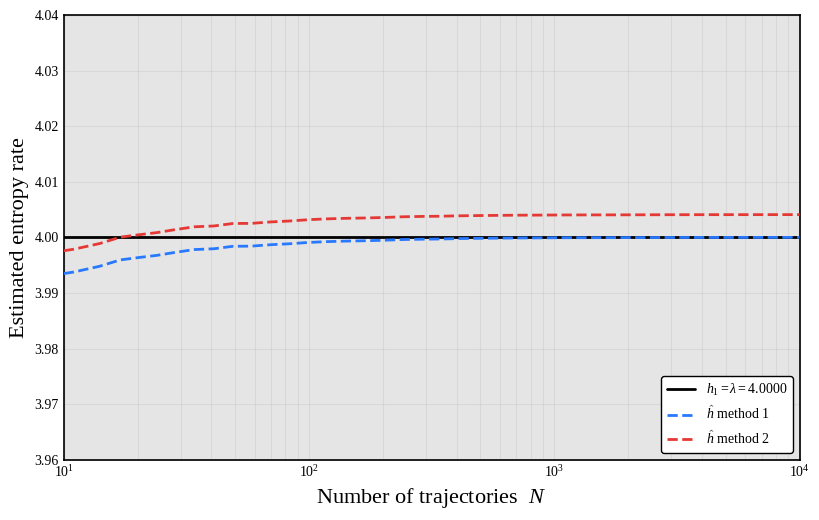

✓ Figura salvata.


In [14]:
# ── Calcolo e visualizzazione curve di convergenza ─────────────
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

C_TH  = "#000000"
C_M1  = "#2979FF"
C_M2  = "#E53935"
BG    = "white"
GRID  = "#DDDDDD"

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Liberation Serif"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Liberation Serif",
    "mathtext.it": "Liberation Serif:italic",
    "mathtext.bf": "Liberation Serif:bold",
})

LABEL_KW  = dict(fontsize=16, fontfamily="Liberation Serif", color="black")
LEGEND_KW = dict(
    fontsize=10, facecolor="white", edgecolor="black", labelcolor="black",
    prop={"family": "Liberation Serif"}, framealpha=1.0, frameon=True,
)


# ── Figura ─────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5), facecolor=BG)
fig1.patch.set_facecolor(BG)
ax1.patch.set_facecolor(BG)
for spine in ax1.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.2)

ax1.fill_between(n_arr, h_theoretical*0.99, h_theoretical*1.01,
                 alpha=0.10, color=C_TH, zorder=1)
ax1.axhline(h_theoretical, color=C_TH, lw=2, linestyle='-', zorder=2,
            label=f'$h_1 = \\lambda = {h_theoretical:.4f}$')
ax1.plot(n_arr, h1_curve, color=C_M1, lw=2.0, zorder=3, linestyle='--',
         label='$\hat{h}$ method 1')
ax1.plot(n_arr, h2_curve, color=C_M2, lw=2.0, zorder=3, linestyle='--',
         label='$\hat{h}$ method 2')

ax1.set_xscale('log')
ax1.set_xlabel('Number of trajectories  $N$', **LABEL_KW)
ax1.set_ylabel('Estimated entropy rate', **LABEL_KW)
ax1.legend(**LEGEND_KW, loc='lower right')
ax1.grid(True, which='both', alpha=0.4, color=GRID)
ax1.tick_params(colors='black')

ax1.margins(0)
ax1.set_xlim(n_arr[0], n_arr[-1])
plt.tight_layout(pad=0)

plt.savefig('fig1_convergenza.pdf', dpi=150, bbox_inches='tight', facecolor=BG, pad_inches=0)
plt.savefig('fig1_convergenza.png', dpi=150, bbox_inches='tight', facecolor=BG, pad_inches=0)
plt.show()
print("✓ Figura salvata.")

In [ ]:
import pickle

save_path_conv = '/content/drive/MyDrive/ruelle_bowen_results/convergences_T3500.pkl'
with open(save_path_conv, 'wb') as f:
    pickle.dump({
        'n_arr':         n_arr,
        'h1_curve':      h1_curve,
        'h2_curve':      h2_curve,
        'h_theoretical': h_theoretical,
        'n_total':       n_total,
        'T':             3500,
    }, f)

print(f"✓ Salvato in '{save_path_conv}'")

✓ Salvato in '/content/drive/MyDrive/ruelle_bowen_results/convergences_T3500.pkl'


In [ ]:
import pickle

load_path_conv = '/content/drive/MyDrive/ruelle_bowen_results/convergences_T3500.pkl'
with open(load_path_conv, 'rb') as f:
    conv = pickle.load(f)

n_arr         = conv['n_arr']
h1_curve      = conv['h1_curve']
h2_curve      = conv['h2_curve']
h_theoretical = conv['h_theoretical']
n_total       = conv['n_total']

print(f"✓ Caricato '{load_path_conv}'")
print(f"  Checkpoint: {len(n_arr)},  N_max: {n_total:,}")
print(f"  h1 finale:  {h1_curve[-1]:.6f}")
print(f"  h2 finale:  {h2_curve[-1]:.6f}")
print(f"  h teorico:  {h_theoretical:.6f}")

✓ Caricato '/content/drive/MyDrive/ruelle_bowen_results/convergences_T3500.pkl'
  Checkpoint: 40,  N_max: 10,000
  h1 finale:  3.999993
  h2 finale:  4.004089
  h teorico:  5.826383


✓ Curve caricate  (40 checkpoint, N_max=10,000)


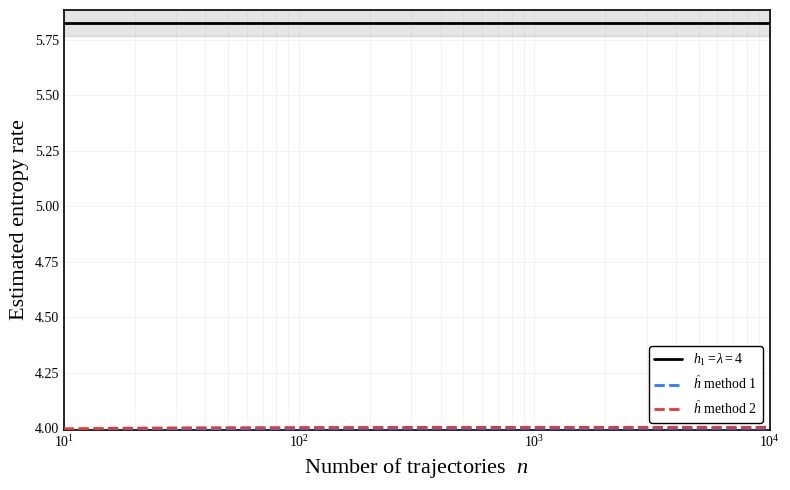

Figura 1 salvata.


In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ── Carica curve ──────────────────────────────────────────────
save_path_conv = '/content/drive/MyDrive/ruelle_bowen_results/convergences_T3500.pkl'
with open(save_path_conv, 'rb') as f:
    conv = pickle.load(f)

h1_curve      = conv['h1_curve']
h2_curve      = conv['h2_curve']
n_arr         = conv['n_arr']
h_theoretical = conv['h_theoretical']
n_total       = conv['n_total']

print(f'✓ Curve caricate  ({len(n_arr)} checkpoint, N_max={n_total:,})')

# ── Palette e stile ────────────────────────────────────────────
C_TH  = "#000000"
C_M1  = "#2979FF"
C_M2  = "#E53935"
BG    = "white"
GRID  = "#DDDDDD"

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Liberation Serif"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Liberation Serif",
    "mathtext.it": "Liberation Serif:italic",
    "mathtext.bf": "Liberation Serif:bold",
})

LABEL_KW  = dict(fontsize=16, fontfamily="Liberation Serif", color="black")
LEGEND_KW = dict(
    fontsize=10,
    facecolor="white",
    edgecolor="black",
    labelcolor="black",
    prop={"family": "Liberation Serif"},
    framealpha=1.0,
    frameon=True,
)

# ── Figura ─────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(8, 5), facecolor=BG)
ax1.set_facecolor(BG)
for spine in ax1.spines.values():
    spine.set_edgecolor("black")
    spine.set_linewidth(1.2)

ax1.fill_between(n_arr, h_theoretical*0.99, h_theoretical*1.01,
                 alpha=0.10, color=C_TH, zorder=1)
ax1.axhline(h_theoretical, color=C_TH, lw=2, linestyle='-', zorder=2,
            label=f'$h_1 = \\lambda=4$')
ax1.plot(n_arr, h1_curve, color=C_M1, lw=2.0, zorder=3, linestyle='--',
         label='$\hat{h}$ method 1')
ax1.plot(n_arr, h2_curve, color=C_M2, lw=2.0, zorder=3, linestyle='--',
         label='$\hat{h}$ method 2')

ax1.set_xscale('log')
ax1.set_xlabel('Number of trajectories  $n$', **LABEL_KW)
ax1.set_ylabel('Estimated entropy rate', **LABEL_KW)
ax1.legend(**LEGEND_KW, loc='lower right')
ax1.grid(True, which='both', alpha=0.4)
ax1.tick_params(colors='black')

ax1.margins(0)
ax1.set_xlim(n_arr[0], n_arr[-1])
plt.tight_layout(pad=0)

plt.tight_layout()
plt.savefig('fig1_convergenza.pdf', dpi=150, bbox_inches='tight',
            facecolor=BG, pad_inches=0.05)
plt.savefig('fig1_convergenza.png', dpi=150, bbox_inches='tight',
            facecolor=BG, pad_inches=0.05)
plt.show()
print("Figura 1 salvata.")

In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  STEP 6 — EQUIPROBABILITY OF TRAJECTORIES  (with time-window filter)   ║
# ║                                                                          ║
# ║  Theorem 2 requires THREE conditions to be identical across all paths:  ║
# ║    1. Same start node  i                                                 ║
# ║    2. Same end node    j                                                 ║
# ║    3. Same number of jumps  N                                            ║
# ║    4. Same time window  [0, t_f]  ← THIS was missing in the old cell   ║
# ║                                                                          ║
# ║  Why it still worked before: the factorisation in the proof shows that  ║
# ║  P(t_N ≤ t_f < t_{N+1}) multiplies every path-probability equally, so  ║
# ║  uniformity is preserved regardless of t_f. Nevertheless, adding the    ║
# ║  time-window filter makes the verification a literal match to the       ║
# ║  theorem statement and removes any residual doubt.                       ║
# ║                                                                          ║
# ║  Strategy: we discretise the time axis into bins of width t_bin and     ║
# ║  keep only trajectories whose total duration falls in the SAME bin.     ║
# ║  We then group by (start, end, n_jumps, time_bin) and run the same      ║
# ║  chi-squared uniformity test as before.                                  ║
# ╚══════════════════════════════════════════════════════════════════════════╝

from scipy.stats import chi2
from collections import defaultdict, Counter
import numpy as np
from tqdm import tqdm

# ── 1.  Generate short trajectories (same as before) ──────────────────────
n_short_steps = 4       # N fixed number of jumps
n_short_trajs = 500_000

print("=" * 60)
print("EQUIPROBABILITY VERIFICATION  —  WITH TIME-WINDOW FILTER")
print("=" * 60)
print(f"\nGenerating {n_short_trajs} trajectories with exactly {n_short_steps} jumps …")

short_trajectories  = []   # list of node sequences
short_waiting_times = []   # list of waiting-time lists

for _ in tqdm(range(n_short_trajs)):
    traj, waits, _ = rb_ctmc.generate_trajectory(n_short_steps)
    short_trajectories.append(traj)
    short_waiting_times.append(waits)

# ── 2.  Choose time-bin width ──────────────────────────────────────────────
# Each trajectory consists of n_short_steps exponential(λ_A) waiting times,
# so the total duration T follows a Gamma(n_short_steps, 1/λ_A) distribution.
# Mean = n_short_steps / λ_A,  Std = sqrt(n_short_steps) / λ_A.
#
# We bin the time axis into intervals of width  t_bin = std / 2  so that
# each bin is narrow (good approximation to a fixed t_f) while still
# containing enough trajectories for a meaningful chi-squared test.

mean_T  = n_short_steps / lattice.lambda_A
std_T   = np.sqrt(n_short_steps) / lattice.lambda_A
t_bin   = std_T / 2          # bin width — adjust freely

print(f"\nTime-window parameters:")
print(f"  Expected total duration  E[T] = {mean_T:.4f}")
print(f"  Std of total duration  Std[T] = {std_T:.4f}")
print(f"  Bin width  t_bin               = {t_bin:.4f}   (= Std/2)")

# ── 3.  Build signature → path list, now INCLUDING the time bin ───────────
#  signature = (start_node, end_node, n_jumps, time_bin_index)

def time_bin_index(waiting_times, t_bin):
    """Return the integer index of the bin that contains sum(waiting_times)."""
    return int(np.floor(sum(waiting_times) / t_bin))

signature_to_paths = defaultdict(list)   # sig → list of path tuples

for traj, waits in zip(short_trajectories, short_waiting_times):
    start   = traj[0]
    end     = traj[-1]
    n_jumps = len(traj) - 1
    bin_idx = time_bin_index(waits, t_bin)

    sig  = (start, end, n_jumps, bin_idx)
    path = tuple(traj)
    signature_to_paths[sig].append(path)

# ── 4.  Filter signatures with enough statistics ──────────────────────────
min_expected_per_path = 5.0
min_total_obs         = 100
max_num_paths         = 100

multi_path_signatures = {}
for sig, paths in signature_to_paths.items():
    unique_paths      = list(set(paths))
    path_counts       = Counter(paths)
    total_obs         = sum(path_counts.values())
    expected_per_path = total_obs / len(unique_paths)

    if (len(unique_paths) > 1
            and expected_per_path >= min_expected_per_path
            and total_obs         >= min_total_obs
            and len(unique_paths) <= max_num_paths):

        multi_path_signatures[sig] = {
            'paths':             unique_paths,
            'counts':            path_counts,
            'total_obs':         total_obs,
            'expected_per_path': expected_per_path,
            'num_paths':         len(unique_paths),
            'time_bin_lo':       sig[3] * t_bin,          # lower edge of bin
            'time_bin_hi':       (sig[3] + 1) * t_bin,    # upper edge of bin
        }

print(f"\nFiltering criteria:")
print(f"  Min expected per path : {min_expected_per_path}")
print(f"  Min total observations: {min_total_obs}")
print(f"  Max distinct paths    : {max_num_paths}")
print(f"\nFound {len(multi_path_signatures)} signatures meeting criteria "
      f"(with time-window conditioning)")

# ── 5.  Run chi-squared uniformity tests ──────────────────────────────────
if len(multi_path_signatures) == 0:
    print("\n⚠  No signatures meet the criteria.")
    print("   Try: reducing n_short_steps, increasing n_short_trajs,")
    print("        relaxing filters, or increasing t_bin.")
else:
    sorted_signatures = sorted(
        multi_path_signatures.items(),
        key=lambda x: x[1]['expected_per_path'],
        reverse=True
    )

    n_best   = min(5, len(sorted_signatures))
    n_random = min(5, max(0, len(sorted_signatures) - n_best))

    test_cases = sorted_signatures[:n_best]
    if n_random > 0 and len(sorted_signatures) > n_best:
        remaining     = sorted_signatures[n_best:]
        random_idx    = np.random.choice(len(remaining),
                                         size=min(n_random, len(remaining)),
                                         replace=False)
        test_cases   += [remaining[i] for i in random_idx]

    print(f"\nTesting equiprobability (top {n_best} best + {n_random} random):")
    print("=" * 60)

    chi_squared_results = []
    all_deviations      = []

    for idx, (sig, data) in enumerate(test_cases):
        start, end, n_jumps, bin_idx = sig
        paths             = data['paths']
        path_counts       = data['counts']
        total_obs         = data['total_obs']
        expected_per_path = data['expected_per_path']
        t_lo              = data['time_bin_lo']
        t_hi              = data['time_bin_hi']

        case_type = "BEST" if idx < n_best else "RANDOM"

        print(f"\nCase {idx+1} [{case_type}]: "
              f"Start={start}, End={end}, N_jumps={n_jumps}")
        print(f"  Time window : [{t_lo:.4f},  {t_hi:.4f}]   "    # ← NEW
              f"(width = {t_bin:.4f})")
        print(f"  Distinct paths    : {len(paths)}")
        print(f"  Total observations: {total_obs}")
        print(f"  Expected per path : {expected_per_path:.1f}")

        # Observed and expected counts
        observed = np.array([path_counts[p] for p in paths])
        expected = np.full(len(paths), total_obs / len(paths))

        # Chi-squared test for uniformity
        chi2_stat    = np.sum((observed - expected) ** 2 / expected)
        df           = len(paths) - 1
        p_value_chi  = 1 - chi2.cdf(chi2_stat, df)
        chi_squared_results.append(p_value_chi)

        # Relative deviations
        rel_dev      = np.abs(observed - expected) / expected
        max_dev      = np.max(rel_dev)
        mean_dev     = np.mean(rel_dev)
        all_deviations.append(mean_dev)

        print(f"  Chi-squared test:")
        print(f"    χ²={chi2_stat:.4f}  (df={df}),  "
              f"p-value={p_value_chi:.4f}  "
              f"→ {'PASS ✓' if p_value_chi > 0.05 else 'FAIL ✗'}")
        print(f"  Deviation from uniformity:")
        print(f"    Max = {max_dev*100:.1f}%,  Mean = {mean_dev*100:.1f}%")

        # Show top-5 path frequencies
        freq_pct      = observed / total_obs * 100
        expected_pct  = 100.0 / len(paths)
        print(f"  Path frequency distribution:")
        print(f"    Expected each : {expected_pct:.2f}%")
        print(f"    Observed range: [{np.min(freq_pct):.2f}%,  "
              f"{np.max(freq_pct):.2f}%]")
        print(f"    Std deviation : {np.std(freq_pct):.2f}%")

        if idx < 3:
            print(f"  Example path frequencies (top 5 / {len(paths)}):")
            for p in sorted(paths, key=lambda p: path_counts[p], reverse=True)[:5]:
                cnt = path_counts[p]
                pct = cnt / total_obs * 100
                print(f"    {p}: {cnt}  ({pct:.2f}%,  expected {expected_pct:.2f}%)")

    # ── 6. Summary ─────────────────────────────────────────────────────────
    print(f"\n{'=' * 60}")
    print("STATISTICAL SUMMARY")
    print("=" * 60)
    n_tests  = len(chi_squared_results)
    n_passed = sum(p > 0.05 for p in chi_squared_results)
    print(f"Tests performed        : {n_tests}")
    print(f"Tests passed (p > 0.05): {n_passed}/{n_tests}")
    print(f"Pass rate              : {n_passed/n_tests*100:.1f}%")
    print(f"\nP-value statistics:")
    print(f"  Mean   = {np.mean(chi_squared_results):.4f}")
    print(f"  Median = {np.median(chi_squared_results):.4f}")
    print(f"  Min    = {np.min(chi_squared_results):.4f}")
    print(f"  Max    = {np.max(chi_squared_results):.4f}")
    print(f"\nDeviation from uniformity:")
    print(f"  Mean = {np.mean(all_deviations)*100:.2f}%")
    print(f"  Max  = {np.max(all_deviations)*100:.2f}%")
    print(f"\nTime-window bin width used: {t_bin:.4f}  (= Std[T] / 2)")

    print(f"\n{'=' * 60}")
    pass_rate = n_passed / n_tests
    if pass_rate == 1.0:
        print("✓ ALL TESTS PASSED — Equiprobability strongly confirmed!")
    elif pass_rate >= 0.95:
        print("✓ EXCELLENT — Very strong evidence for equiprobability")
    elif pass_rate >= 0.90:
        print("✓ GOOD — Strong evidence for equiprobability")
    elif pass_rate >= 0.80:
        print("⚠ ACCEPTABLE — Moderate evidence for equiprobability")
    else:
        print("✗ WEAK — Insufficient evidence for equiprobability")
    print("=" * 60)

EQUIPROBABILITY VERIFICATION  —  WITH TIME-WINDOW FILTER

Generating 500000 trajectories with exactly 4 jumps …


100%|██████████| 500000/500000 [01:49<00:00, 4574.75it/s]



Time-window parameters:
  Expected total duration  E[T] = 1.0000
  Std of total duration  Std[T] = 0.5000
  Bin width  t_bin               = 0.2500   (= Std/2)

Filtering criteria:
  Min expected per path : 5.0
  Min total observations: 100
  Max distinct paths    : 100

Found 1632 signatures meeting criteria (with time-window conditioning)

Testing equiprobability (top 5 best + 5 random):

Case 1 [BEST]: Start=16, End=19, N_jumps=4
  Time window : [0.5000,  0.7500]   (width = 0.2500)
  Distinct paths    : 8
  Total observations: 124
  Expected per path : 15.5
  Chi-squared test:
    χ²=4.1290  (df=7),  p-value=0.7648  → PASS ✓
  Deviation from uniformity:
    Max = 29.0%,  Mean = 15.3%
  Path frequency distribution:
    Expected each : 12.50%
    Observed range: [8.87%,  16.13%]
    Std deviation : 2.28%
  Example path frequencies (top 5 / 8):
    (16, np.int64(15), np.int64(21), np.int64(20), np.int64(19)): 20  (16.13%,  expected 12.50%)
    (16, np.int64(15), np.int64(14), np.int64

## 5. Verification 2: Waiting Time Distribution (Exponential with rate λ_A)

Key property: ALL waiting times follow Exp(λ_A), independent of the current state!

WAITING TIME DISTRIBUTION VERIFICATION

Kolmogorov-Smirnov Test:
  H0: Waiting times ~ Exp(λ_A=4.0000)
  KS statistic: 0.000557
  p-value: 0.418793
  Result: PASS ✓ (α=0.01)


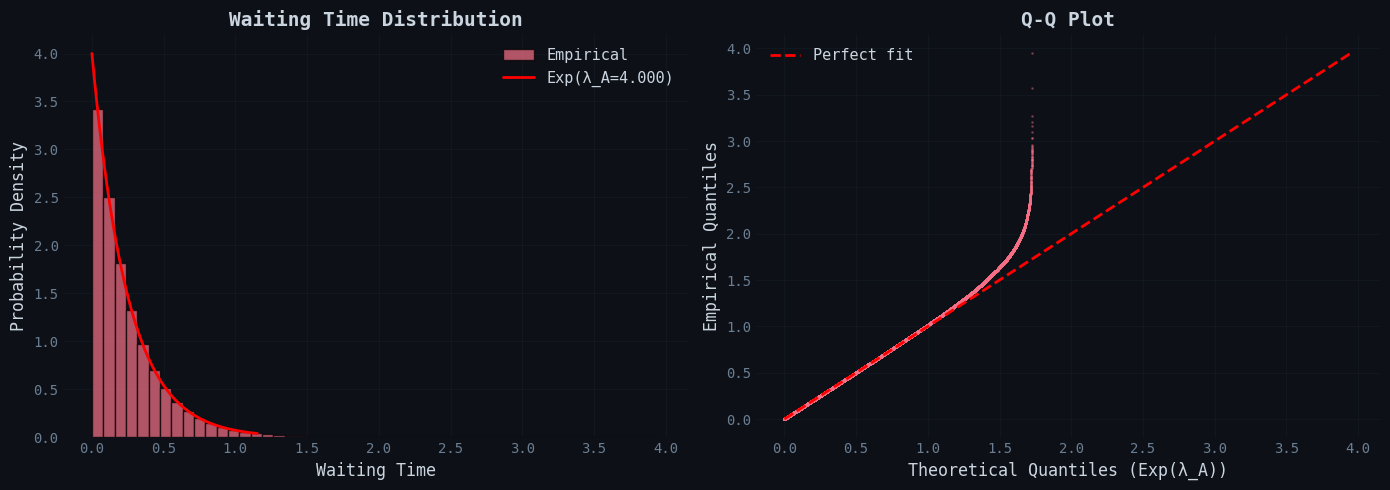


Summary Statistics:
  Empirical mean: 0.250222
  Theoretical mean (1/λ_A): 0.250000
  Empirical std: 0.250297
  Theoretical std (1/λ_A): 0.250000


In [ ]:
print("=" * 60)
print("WAITING TIME DISTRIBUTION VERIFICATION")
print("=" * 60)

# Statistical test: Kolmogorov-Smirnov test
# H0: waiting times ~ Exp(λ_A)
ks_statistic, p_value = kstest(all_waiting_times,
                               lambda x: expon.cdf(x, scale=1/lattice.lambda_A))

print(f"\nKolmogorov-Smirnov Test:")
print(f"  H0: Waiting times ~ Exp(λ_A={lattice.lambda_A:.4f})")
print(f"  KS statistic: {ks_statistic:.6f}")
print(f"  p-value: {p_value:.6f}")
print(f"  Result: {'PASS ✓' if p_value > 0.01 else 'FAIL ✗'} (α=0.01)")

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(all_waiting_times, bins=50, density=True, alpha=0.7,
             label='Empirical', edgecolor='black')
x = np.linspace(0, np.percentile(all_waiting_times, 99), 200)
axes[0].plot(x, expon.pdf(x, scale=1/lattice.lambda_A), 'r-', lw=2,
             label=f'Exp(λ_A={lattice.lambda_A:.3f})')
axes[0].set_xlabel('Waiting Time', fontsize=12)
axes[0].set_ylabel('Probability Density', fontsize=12)
axes[0].set_title('Waiting Time Distribution', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Q-Q plot
theoretical_quantiles = -np.log(1 - np.linspace(0.001, 0.999, len(all_waiting_times))) / lattice.lambda_A
empirical_quantiles = np.sort(all_waiting_times)
axes[1].scatter(theoretical_quantiles, empirical_quantiles, alpha=0.3, s=1)
max_val = max(theoretical_quantiles.max(), empirical_quantiles.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect fit')
axes[1].set_xlabel('Theoretical Quantiles (Exp(λ_A))', fontsize=12)
axes[1].set_ylabel('Empirical Quantiles', fontsize=12)
axes[1].set_title('Q-Q Plot', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Summary statistics
print(f"\nSummary Statistics:")
print(f"  Empirical mean: {np.mean(all_waiting_times):.6f}")
print(f"  Theoretical mean (1/λ_A): {1/lattice.lambda_A:.6f}")
print(f"  Empirical std: {np.std(all_waiting_times):.6f}")
print(f"  Theoretical std (1/λ_A): {1/lattice.lambda_A:.6f}")

# 6. Verification 3: Equiprobability of Trajectories with same total time interval condition

Theorem 2 from paper: The probability of transitioning from node i to node j via a sequence of precisely N nodes over a specified interval of time is independent of the particular sequence.

## genero traiettorie

In [ ]:
# ─── Parameters ───────────────────────────────────────────────────────────────
lambda_A     = rb_ctmc.lambda_A          # = 4.0 for regular lattice
N_target     = 4                         # target number of jumps
tf           = N_target / lambda_A       # = 1.0,  peak of Gamma(N, 1/λ_A)
epsilon      = 0.05                      # acceptance window: [tf-ε, tf+ε]
n_trajs      = 10_000_000                 # large number needed due to filtering

# Robustness thresholds
min_expected_per_path = 5.0
min_total_obs         = 100
max_num_paths         = 100
# ──────────────────────────────────────────────────────────────────────────────


In [ ]:
from scipy.stats import chi2, gamma

def extract_path_signature(trajectory, n_jumps):
    """Extract (start, end, n_jumps) signature and the actual path"""
    start  = trajectory[0]
    end    = trajectory[-1]
    path   = tuple(trajectory)
    return (start, end, n_jumps), path

print("=" * 60)
print("EQUIPROBABILITY OF TRAJECTORIES - THEOREM 2 VERIFICATION")
print("(Option A: fixed tf, fixed N, using generate_trajectory)")
print("=" * 60)

# ─── Parameters ───────────────────────────────────────────────────────────────
lambda_A     = rb_ctmc.lambda_A          # = 4.0 for regular lattice
N_target     = 4                         # target number of jumps
tf           = N_target / lambda_A       # = 1.0,  peak of Gamma(N, 1/λ_A)
epsilon      = 0.05                      # acceptance window: [tf-ε, tf+ε]
n_trajs      = 10_000_000                 # large number needed due to filtering

# Robustness thresholds
min_expected_per_path = 5.0
min_total_obs         = 100
max_num_paths         = 100
# ──────────────────────────────────────────────────────────────────────────────

print(f"\nFixed parameters:")
print(f"  λ_A              : {lambda_A:.4f}")
print(f"  Target N jumps   : {N_target}")
print(f"  Target tf        : {tf:.4f}  (= N/λ_A)")
print(f"  Epsilon window   : ±{epsilon}  →  [{tf-epsilon:.4f}, {tf+epsilon:.4f}]")
print(f"  Theoretical acceptance rate: "
      f"{gamma.cdf(tf+epsilon, a=N_target, scale=1/lambda_A) - gamma.cdf(tf-epsilon, a=N_target, scale=1/lambda_A):.3f}"
      f"  (Gamma({N_target}, 1/λ_A))")
print(f"\nGenerating {n_trajs:,} trajectories...")

# ─── Generate and filter ───────────────────────────────────────────────────────
accepted_trajectories = []
accepted_njumps       = []
n_generated           = 0

for _ in tqdm(range(n_trajs)):
    # generate_trajectory(T) runs until time T is exceeded
    # we use tf+epsilon as the time budget so trajectories
    # that complete N_target jumps within [tf-ε, tf+ε] are captured
    traj, times, n_jumps = rb_ctmc.generate_trajectory(tf + epsilon)
    n_generated += 1

    # Filter: must have exactly N_target jumps AND total duration in window
    total_duration = sum(times)
    if n_jumps == N_target and abs(total_duration - tf) <= epsilon:
        accepted_trajectories.append(traj)
        accepted_njumps.append(n_jumps)

n_accepted       = len(accepted_trajectories)
acceptance_rate  = n_accepted / n_trajs * 100
print(f"\nAccepted: {n_accepted:,} / {n_trajs:,}  ({acceptance_rate:.2f}%)")

if n_accepted == 0:
    print("\n⚠  No trajectories accepted.")
    print("Try: increasing epsilon, increasing n_trajs.")
else:
    # ─── Group by (start, end, n_jumps) ───────────────────────────────────────
    # n_jumps is always N_target here, but kept in signature for clarity
    signature_to_paths = defaultdict(list)
    for traj, n_jumps in zip(accepted_trajectories, accepted_njumps):
        sig, path = extract_path_signature(traj, n_jumps)
        signature_to_paths[sig].append(path)

    # ─── Filter signatures ─────────────────────────────────────────────────────
    multi_path_signatures = {}
    for sig, paths in signature_to_paths.items():
        unique_paths      = list(set(paths))
        path_counts       = Counter(paths)
        total_obs         = sum(path_counts.values())
        expected_per_path = total_obs / len(unique_paths)

        if (len(unique_paths) > 1
                and expected_per_path >= min_expected_per_path
                and total_obs         >= min_total_obs
                and len(unique_paths) <= max_num_paths):
            multi_path_signatures[sig] = {
                'paths':             unique_paths,
                'counts':            path_counts,
                'total_obs':         total_obs,
                'expected_per_path': expected_per_path,
                'num_paths':         len(unique_paths)
            }

    print(f"\nFiltering criteria:")
    print(f"  Min expected per path : {min_expected_per_path}")
    print(f"  Min total observations: {min_total_obs}")
    print(f"  Max number of paths   : {max_num_paths}")
    print(f"\nSignatures meeting criteria: {len(multi_path_signatures)}")

    if len(multi_path_signatures) == 0:
        print("\n⚠  No signatures meet robustness criteria.")
        print("Try: increasing epsilon, increasing n_trajs, or relaxing filters.")
    else:
        sorted_signatures = sorted(
            multi_path_signatures.items(),
            key=lambda x: x[1]['expected_per_path'],
            reverse=True
        )

        n_best   = min(5, len(sorted_signatures))
        n_random = min(5, max(0, len(sorted_signatures) - n_best))

        test_cases = sorted_signatures[:n_best]
        if n_random > 0:
            remaining  = sorted_signatures[n_best:]
            rand_idx   = np.random.choice(len(remaining), size=n_random, replace=False)
            test_cases += [remaining[i] for i in rand_idx]

        print(f"\nTesting equiprobability:")
        print(f"  Top {n_best} (highest expected per path) + {n_random} random")
        print(f"  Total: {len(test_cases)} tests")
        print("=" * 60)

        chi_squared_results = []
        all_deviations      = []

        for idx, (sig, data) in enumerate(test_cases):
            start, end, n_jumps = sig
            paths             = data['paths']
            path_counts       = data['counts']
            total_obs         = data['total_obs']
            expected_per_path = data['expected_per_path']
            case_type         = "BEST" if idx < n_best else "RANDOM"

            print(f"\nCase {idx+1} [{case_type}]: Start={start}, End={end}, "
                  f"N={n_jumps}, tf={tf:.3f}±{epsilon}")
            print(f"  Distinct paths     : {len(paths)}")
            print(f"  Total observations : {total_obs}")
            print(f"  Expected per path  : {expected_per_path:.1f}")

            observed    = np.array([path_counts[p] for p in paths])
            expected    = np.full(len(paths), total_obs / len(paths))
            chi2_stat   = np.sum((observed - expected)**2 / expected)
            df          = len(paths) - 1
            p_value_chi = 1 - chi2.cdf(chi2_stat, df)

            chi_squared_results.append(p_value_chi)

            rel_deviations = np.abs(observed - expected) / expected
            max_deviation  = np.max(rel_deviations)
            mean_deviation = np.mean(rel_deviations)
            all_deviations.append(mean_deviation)

            print(f"  Chi-squared test:")
            print(f"    χ² statistic : {chi2_stat:.4f}  (df={df})")
            print(f"    p-value      : {p_value_chi:.4f}")
            print(f"    Result       : {'PASS ✓' if p_value_chi > 0.05 else 'FAIL ✗'}  (α=0.05)")
            print(f"  Deviation from uniformity:")
            print(f"    Max relative : {max_deviation*100:.1f}%")
            print(f"    Mean relative: {mean_deviation*100:.1f}%")

            freq_pct     = observed / total_obs * 100
            expected_pct = 100.0 / len(paths)
            print(f"  Path frequency distribution:")
            print(f"    Expected each  : {expected_pct:.2f}%")
            print(f"    Observed range : [{np.min(freq_pct):.2f}%, {np.max(freq_pct):.2f}%]")
            print(f"    Std deviation  : {np.std(freq_pct):.2f}%")

            if idx < 3:
                print(f"  Example paths (top 5 / {len(paths)}):")
                for p in sorted(paths, key=lambda p: path_counts[p], reverse=True)[:5]:
                    cnt = path_counts[p]
                    print(f"    {p}: {cnt}  ({cnt/total_obs*100:.2f}%,  expected {expected_pct:.2f}%)")

        print(f"\n{'='*60}")
        print("STATISTICAL SUMMARY")
        print("=" * 60)
        n_pass    = sum(p > 0.05 for p in chi_squared_results)
        pass_rate = n_pass / len(chi_squared_results)
        print(f"Tests performed       : {len(chi_squared_results)}")
        print(f"Tests passed (p>0.05) : {n_pass}/{len(chi_squared_results)}")
        print(f"Pass rate             : {pass_rate*100:.1f}%")
        print(f"\nP-value statistics:")
        print(f"  Mean  : {np.mean(chi_squared_results):.4f}")
        print(f"  Median: {np.median(chi_squared_results):.4f}")
        print(f"  Min   : {np.min(chi_squared_results):.4f}")
        print(f"  Max   : {np.max(chi_squared_results):.4f}")
        print(f"\nDeviation from uniformity:")
        print(f"  Mean: {np.mean(all_deviations)*100:.2f}%")
        print(f"  Max : {np.max(all_deviations)*100:.2f}%")

        print(f"\n{'='*60}")
        if pass_rate == 1.0:
            print("✓ ALL TESTS PASSED - Theorem 2 fully confirmed!")
        elif pass_rate >= 0.95:
            print("✓ EXCELLENT - Very strong evidence for Theorem 2")
        elif pass_rate >= 0.90:
            print("✓ GOOD - Strong evidence for Theorem 2")
        elif pass_rate >= 0.80:
            print("⚠ ACCEPTABLE - Moderate evidence for Theorem 2")
        else:
            print("✗ WEAK - Insufficient evidence for Theorem 2")
        print("=" * 60)

EQUIPROBABILITY OF TRAJECTORIES - THEOREM 2 VERIFICATION
(Option A: fixed tf, fixed N, using generate_trajectory)

Fixed parameters:
  λ_A              : 4.0000
  Target N jumps   : 4
  Target tf        : 1.0000  (= N/λ_A)
  Epsilon window   : ±0.05  →  [0.9500, 1.0500]
  Theoretical acceptance rate: 0.078  (Gamma(4, 1/λ_A))

Generating 10,000,000 trajectories...


100%|██████████| 10000000/10000000 [32:26<00:00, 5136.62it/s]



Accepted: 641,158 / 10,000,000  (6.41%)

Filtering criteria:
  Min expected per path : 5.0
  Min total observations: 100
  Max number of paths   : 100

Signatures meeting criteria: 612

Testing equiprobability:
  Top 5 (highest expected per path) + 5 random
  Total: 10 tests

Case 1 [BEST]: Start=6, End=15, N=4, tf=1.000±0.05
  Distinct paths     : 8
  Total observations : 615
  Expected per path  : 76.9
  Chi-squared test:
    χ² statistic : 5.4228  (df=7)
    p-value      : 0.6085
    Result       : PASS ✓  (α=0.05)
  Deviation from uniformity:
    Max relative : 16.7%
    Mean relative: 8.3%
  Path frequency distribution:
    Expected each  : 12.50%
    Observed range : [10.41%, 13.66%]
    Std deviation  : 1.17%
  Example paths (top 5 / 8):
    (6, np.int64(7), np.int64(13), np.int64(14), np.int64(15)): 84  (13.66%,  expected 12.50%)
    (6, np.int64(7), np.int64(8), np.int64(9), np.int64(15)): 83  (13.50%,  expected 12.50%)
    (6, np.int64(7), np.int64(8), np.int64(14), np.int64

## salvo le traiettorie generate

In [ ]:
import pickle
import os
from google.colab import drive

drive.mount('/content/drive')

SAVE_DIR = '/content/drive/MyDrive/ruelle_bowen_results'
os.makedirs(SAVE_DIR, exist_ok=True)

payload = {
    'accepted_trajectories':  accepted_trajectories,
    'accepted_njumps':        accepted_njumps,
    'multi_path_signatures':  multi_path_signatures,
    'params': {
        'lambda_A':             lambda_A,
        'N_target':             N_target,
        'tf':                   tf,
        'epsilon':              epsilon,
        'n_trajs':              n_trajs,
        'min_expected_per_path': min_expected_per_path,
        'min_total_obs':        min_total_obs,
        'max_num_paths':        max_num_paths,
    }
}

save_path = os.path.join(SAVE_DIR, f'equiprobability_N{N_target}.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f'✓ Salvato in: {save_path}')
print(f'  Traiettorie accettate  : {len(accepted_trajectories):,}')
print(f'  Firme valide           : {len(multi_path_signatures)}')
print(f'  Dimensione file        : {os.path.getsize(save_path) / 1e6:.2f} MB')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Salvato in: /content/drive/MyDrive/ruelle_bowen_results/equiprobability_N4.pkl
  Traiettorie accettate  : 641,158
  Firme valide           : 612
  Dimensione file        : 54.21 MB


In [29]:
import pickle
from google.colab import drive
from collections import Counter, defaultdict

drive.mount('/content/drive')

load_path = '/content/drive/MyDrive/ruelle_bowen_results/equiprobability_N4.pkl'
with open(load_path, 'rb') as f:
    payload = pickle.load(f)

accepted_trajectories  = payload['accepted_trajectories']
accepted_njumps        = payload['accepted_njumps']
multi_path_signatures  = payload['multi_path_signatures']

lambda_A               = payload['params']['lambda_A']
N_target               = payload['params']['N_target']
tf                     = payload['params']['tf']
epsilon                = payload['params']['epsilon']
n_trajs                = payload['params']['n_trajs']
min_expected_per_path  = payload['params']['min_expected_per_path']
min_total_obs          = payload['params']['min_total_obs']
max_num_paths          = payload['params']['max_num_paths']

print(f'✓ Caricato da: {load_path}')
print(f'  Traiettorie accettate  : {len(accepted_trajectories):,}')
print(f'  Firme valide           : {len(multi_path_signatures)}')
print(f'  Parametri              : N={N_target}, tf={tf:.4f}, ε={epsilon}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Caricato da: /content/drive/MyDrive/ruelle_bowen_results/equiprobability_N4.pkl
  Traiettorie accettate  : 641,158
  Firme valide           : 612
  Parametri              : N=4, tf=1.0000, ε=0.05


## test del chi quadro su 612 signatures

In [30]:
from scipy.stats import chi2

print("=" * 60)
print("EQUIPROBABILITY TEST — 50 BEST + 50 RANDOM SIGNATURES")
print("=" * 60)

sorted_signatures = sorted(
    multi_path_signatures.items(),
    key=lambda x: x[1]['expected_per_path'],
    reverse=True
)

n_best   = min(306, len(sorted_signatures))
n_random = min(306, max(0, len(sorted_signatures) - n_best))

test_cases_ext = sorted_signatures[:n_best]
if n_random > 0:
    remaining  = sorted_signatures[n_best:]
    rand_idx   = np.random.choice(len(remaining), size=n_random, replace=False)
    test_cases_ext += [remaining[i] for i in rand_idx]

print(f"Total signatures available : {len(sorted_signatures)}")
print(f"Top {n_best} (highest expected_per_path) + {n_random} random")
print(f"Total tests                : {len(test_cases_ext)}")
print(f"\nTop 5 signatures by expected_per_path:")
for sig, data in sorted_signatures[:5]:
    start, end, n_jumps = sig
    print(f"  {start}→{end} N={n_jumps}:  "
          f"{data['num_paths']} paths,  "
          f"total_obs={data['total_obs']},  "
          f"expected_per_path={data['expected_per_path']:.1f}")
print("=" * 60)

chi_squared_results_ext = []
all_deviations_ext      = []

for idx, (sig, data) in enumerate(test_cases_ext):
    start, end, n_jumps = sig
    paths             = data['paths']
    path_counts       = data['counts']
    total_obs         = data['total_obs']
    expected_per_path = data['expected_per_path']
    case_type         = "BEST" if idx < n_best else "RANDOM"

    observed    = np.array([path_counts[p] for p in paths])
    expected    = np.full(len(paths), total_obs / len(paths))
    chi2_stat   = np.sum((observed - expected)**2 / expected)
    df          = len(paths) - 1
    p_value_chi = 1 - chi2.cdf(chi2_stat, df)

    chi_squared_results_ext.append(p_value_chi)

    rel_deviations = np.abs(observed - expected) / expected
    all_deviations_ext.append(np.mean(rel_deviations))

    # Verbose only for first 5
    if idx < 5:
        print(f"\nCase {idx+1} [{case_type}]: Start={start}, End={end}, N={n_jumps}")
        print(f"  Distinct paths    : {len(paths)}")
        print(f"  Total obs         : {total_obs}")
        print(f"  Expected per path : {expected_per_path:.1f}")
        print(f"  χ² statistic      : {chi2_stat:.4f}  (df={df})")
        print(f"  p-value           : {p_value_chi:.4f}")
        print(f"  Result            : {'PASS ✓' if p_value_chi > 0.05 else 'FAIL ✗'}")

print(f"\n{'='*60}")
print("STATISTICAL SUMMARY")
print("=" * 60)
pvals_ext = np.array(chi_squared_results_ext)
n_pass    = np.sum(pvals_ext > 0.05)
pass_rate = n_pass / len(pvals_ext)

print(f"Tests performed       : {len(pvals_ext)}")
print(f"Tests passed (p>0.05) : {n_pass}/{len(pvals_ext)}  ({pass_rate*100:.1f}%)")
print(f"\nP-value statistics:")
print(f"  Mean  : {np.mean(pvals_ext):.4f}")
print(f"  Median: {np.median(pvals_ext):.4f}")
print(f"  Min   : {np.min(pvals_ext):.4f}")
print(f"  Max   : {np.max(pvals_ext):.4f}")
print(f"\nDeviation from uniformity:")
print(f"  Mean: {np.mean(all_deviations_ext)*100:.2f}%")
print(f"  Max : {np.max(all_deviations_ext)*100:.2f}%")

print(f"\n{'='*60}")
verdict = (
    "✓ PERFETTO — Teorema 2 confermato"      if pass_rate == 1.0  else
    "✓ OTTIMO   — evidenza molto forte"       if pass_rate >= 0.95 else
    "✓ BUONO    — evidenza forte"             if pass_rate >= 0.90 else
    "⚠ PARZIALE — evidenza moderata"          if pass_rate >= 0.80 else
    "✗ DEBOLE   — evidenza insufficiente"
)
print(f"  Verdetto: {verdict}")
print("=" * 60)

EQUIPROBABILITY TEST — 50 BEST + 50 RANDOM SIGNATURES
Total signatures available : 612
Top 306 (highest expected_per_path) + 306 random
Total tests                : 612

Top 5 signatures by expected_per_path:
  6→15 N=4:  8 paths,  total_obs=615,  expected_per_path=76.9
  24→16 N=4:  6 paths,  total_obs=461,  expected_per_path=76.8
  23→0 N=4:  8 paths,  total_obs=613,  expected_per_path=76.6
  35→7 N=4:  6 paths,  total_obs=457,  expected_per_path=76.2
  32→29 N=4:  8 paths,  total_obs=609,  expected_per_path=76.1

Case 1 [BEST]: Start=6, End=15, N=4
  Distinct paths    : 8
  Total obs         : 615
  Expected per path : 76.9
  χ² statistic      : 5.4228  (df=7)
  p-value           : 0.6085
  Result            : PASS ✓

Case 2 [BEST]: Start=24, End=16, N=4
  Distinct paths    : 6
  Total obs         : 461
  Expected per path : 76.8
  χ² statistic      : 3.6551  (df=5)
  p-value           : 0.6001
  Result            : PASS ✓

Case 3 [BEST]: Start=23, End=0, N=4
  Distinct paths    : 8

## plots verification 3

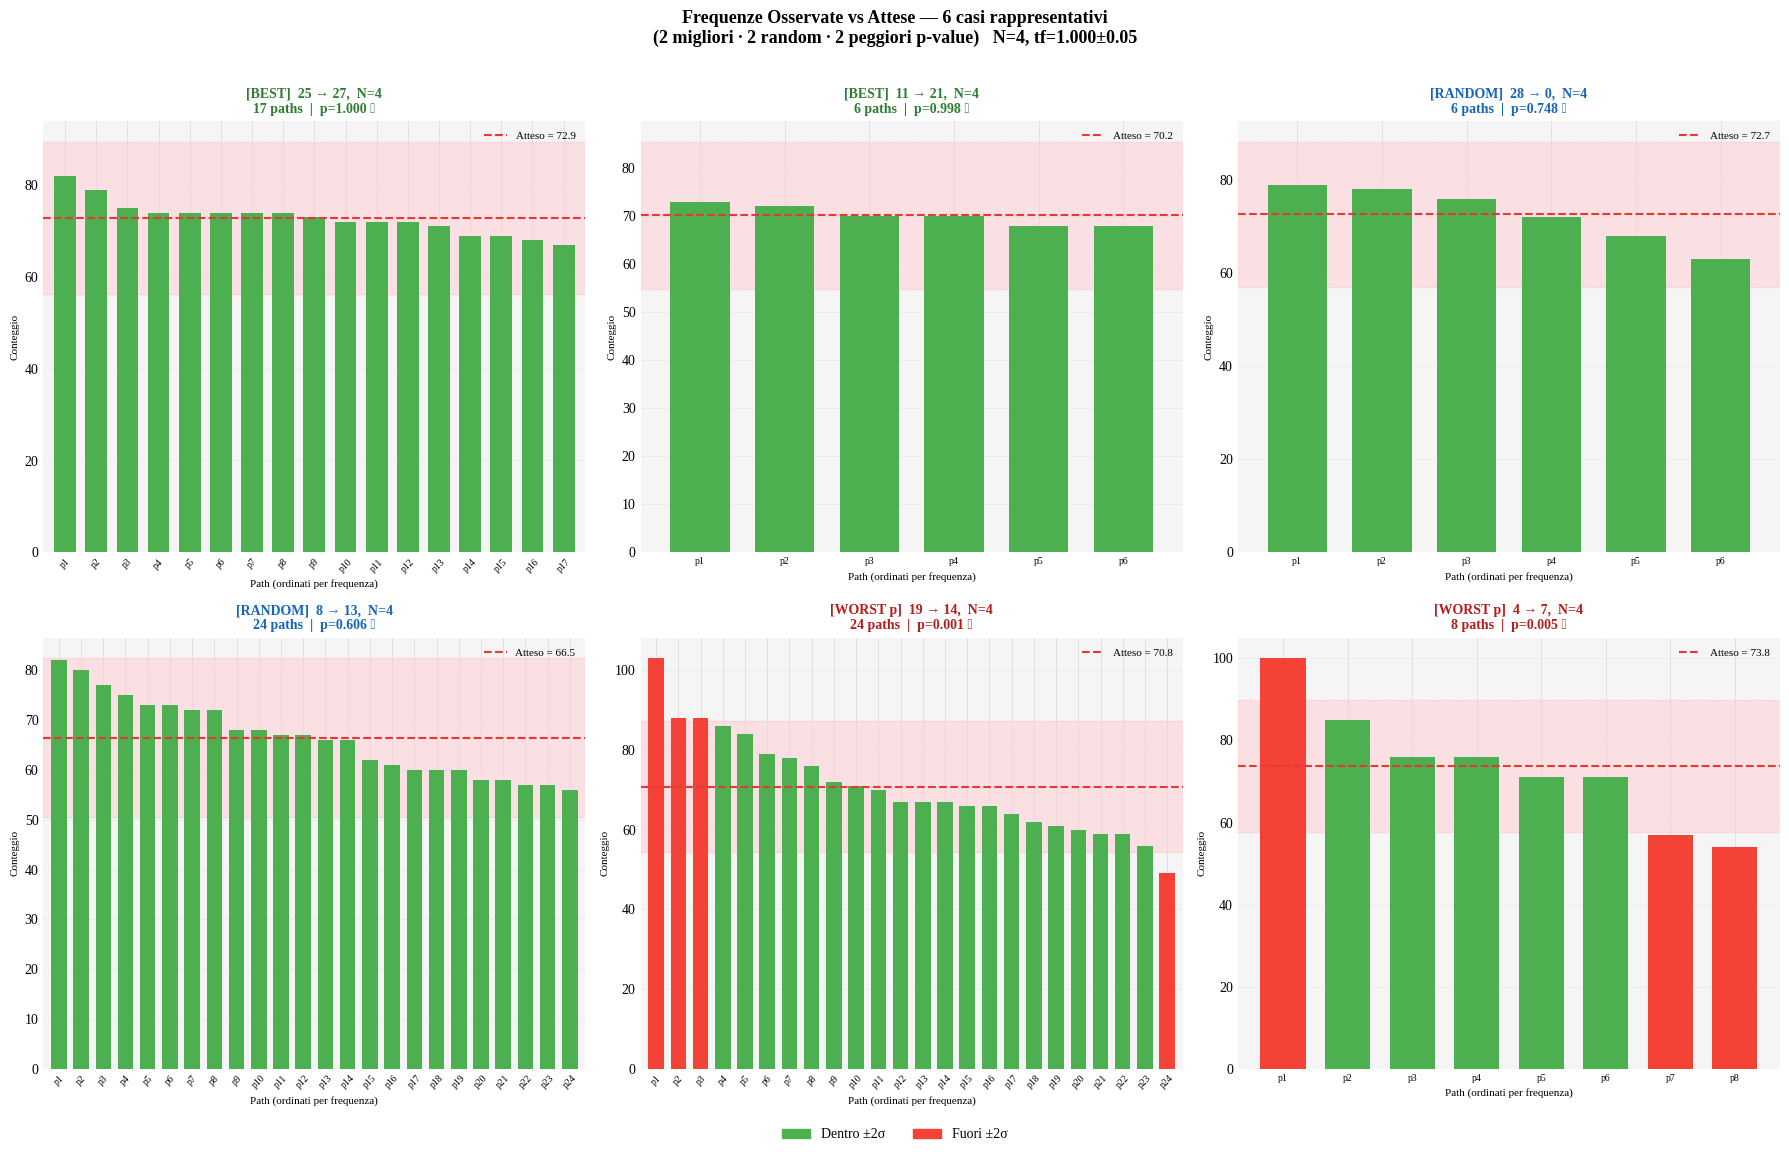

Plot saved to verification3_equiprobability.png


In [31]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  VERIFICATION 3 — EQUIPROBABILITY PLOT                                  ║
# ║  Frequenze Osservate vs Attese — 6 casi rappresentativi                 ║
# ║  (2 migliori · 2 random · 2 peggiori p-value)                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import chi2

# ── Rebuild chi2 results if not already present ──────────────────────────────
# (assumes test_cases_ext and chi_squared_results_ext are defined from cell 32)

# ── Select 6 representative cases ────────────────────────────────────────────
pvals_ext = np.array(chi_squared_results_ext)
sorted_by_pval = np.argsort(pvals_ext)          # ascending: worst first

idx_best   = np.argsort(pvals_ext)[-2:][::-1]  # 2 highest p-values
idx_worst  = np.argsort(pvals_ext)[:2]          # 2 lowest  p-values

# 2 random from the middle
middle_mask = np.ones(len(pvals_ext), dtype=bool)
middle_mask[idx_best]  = False
middle_mask[idx_worst] = False
middle_idx  = np.where(middle_mask)[0]
rng         = np.random.default_rng(42)
idx_random  = rng.choice(middle_idx, size=2, replace=False)

panel_indices = list(idx_best) + list(idx_random) + list(idx_worst)
panel_labels  = ["BEST", "BEST", "RANDOM", "RANDOM", "WORST p", "WORST p"]

# ── Layout ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

C_IN  = "#4CAF50"   # green  — within ±2σ
C_OUT = "#F44336"   # red    — outside ±2σ

for panel, (global_idx, label) in enumerate(zip(panel_indices, panel_labels)):
    ax  = axes[panel]
    sig, data = test_cases_ext[global_idx]
    start, end, n_jumps = sig

    paths             = data['paths']
    path_counts       = data['counts']
    total_obs         = data['total_obs']
    expected_per_path = data['expected_per_path']
    n_paths           = len(paths)

    # Sort paths by observed count descending
    sorted_paths  = sorted(paths, key=lambda p: path_counts[p], reverse=True)
    observed      = np.array([path_counts[p] for p in sorted_paths])
    expected_val  = total_obs / n_paths
    sigma         = np.sqrt(expected_val * (1 - 1/n_paths))   # multinomial std

    x_labels = [f"p{i+1}" for i in range(len(sorted_paths))]
    colors    = [C_IN if abs(o - expected_val) <= 2*sigma else C_OUT
                 for o in observed]

    ax.bar(x_labels, observed, color=colors, width=0.7, zorder=3)

    # Expected line & ±2σ band
    ax.axhline(expected_val, color="#E53935", linestyle="--", linewidth=1.5,
               label=f"Atteso = {expected_val:.1f}", zorder=4)
    ax.axhspan(expected_val - 2*sigma, expected_val + 2*sigma,
               color="#FFCDD2", alpha=0.5, zorder=2)
    ax.axhline(expected_val + 2*sigma, color="#FFCDD2", linewidth=0.8, linestyle=":")
    ax.axhline(expected_val - 2*sigma, color="#FFCDD2", linewidth=0.8, linestyle=":")

    # Legend for expected line (top-right)
    ax.legend(loc="upper right", fontsize=8, framealpha=0.8)

    # p-value
    p_val = pvals_ext[global_idx]

    # Title
    color_title = "#2E7D32" if label.startswith("BEST") else \
                  "#1565C0" if label == "RANDOM"         else "#B71C1C"
    ax.set_title(
        f"[{label}]  {start} → {end},  N={n_jumps}\n"
        f"{n_paths} paths  |  p={p_val:.3f} {'✓' if p_val > 0.05 else '✗'}",
        color=color_title, fontsize=10, fontweight="bold", pad=6
    )

    ax.set_xlabel("Path (ordinati per frequenza)", fontsize=8)
    ax.set_ylabel("Conteggio", fontsize=8)
    ax.tick_params(axis='x', labelsize=7, rotation=45 if n_paths > 12 else 0)
    ax.set_xlim(-0.7, len(sorted_paths) - 0.3)
    ax.grid(axis='y', alpha=0.4, zorder=1)
    ax.set_facecolor("#F5F5F5")

# ── Global title ─────────────────────────────────────────────────────────────
fig.suptitle(
    "Frequenze Osservate vs Attese — 6 casi rappresentativi\n"
    f"(2 migliori · 2 random · 2 peggiori p-value)   "
    f"N={N_target}, tf={tf:.3f}±{epsilon}",
    fontsize=13, fontweight="bold", y=1.01
)

# ── Legend (shared, bottom) ───────────────────────────────────────────────────
patch_in  = mpatches.Patch(color=C_IN,  label="Dentro ±2σ")
patch_out = mpatches.Patch(color=C_OUT, label="Fuori ±2σ")
fig.legend(handles=[patch_in, patch_out],
           loc="lower center", ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.03), framealpha=0.9)

plt.tight_layout()
plt.savefig("verification3_equiprobability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to verification3_equiprobability.png")

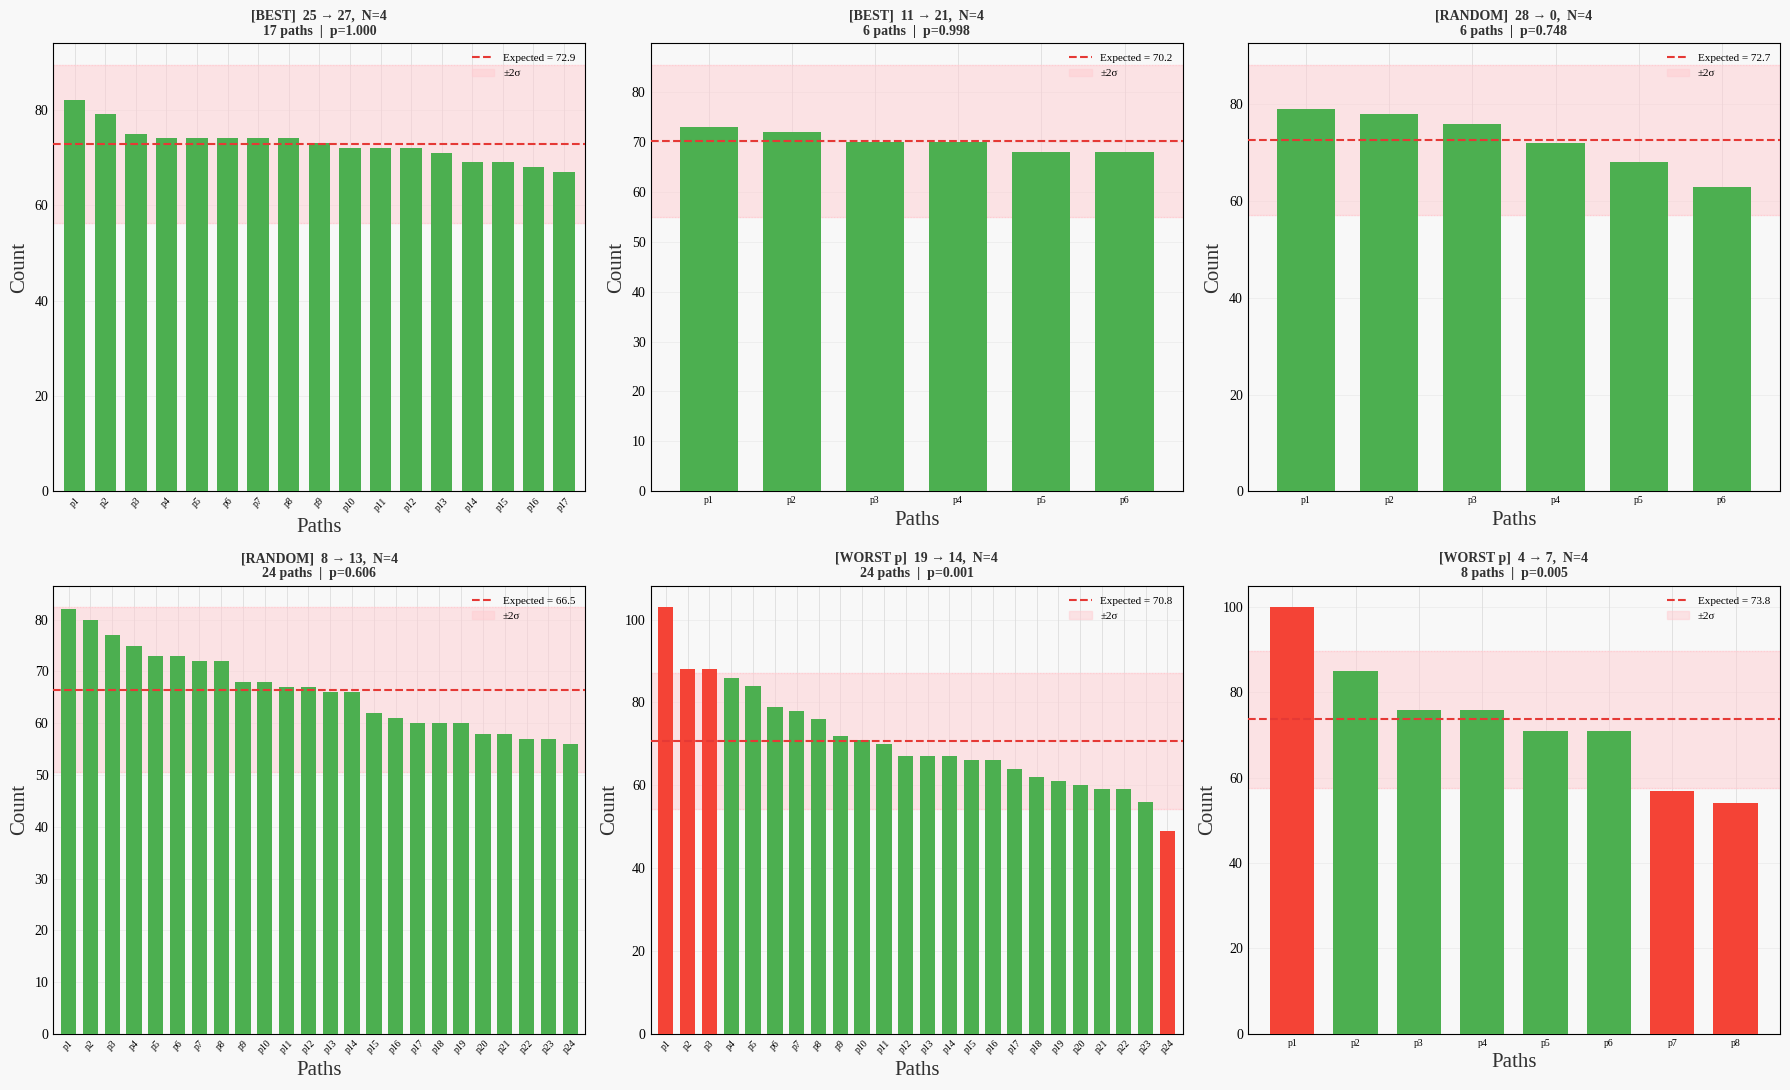

Plot saved to verification3_equiprobability.png


In [40]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║  VERIFICATION 3 — EQUIPROBABILITY PLOT                                  ║
# ║  Frequenze Osservate vs Attese — 6 casi rappresentativi                 ║
# ║  (2 migliori · 2 random · 2 peggiori p-value)                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import chi2

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.serif": ["Liberation Serif"],
    "mathtext.fontset": "custom",
    "mathtext.rm": "Liberation Serif",
    "mathtext.it": "Liberation Serif:italic",
    "mathtext.bf": "Liberation Serif:bold",
})

ALPHA = 0.05
BG    = '#F8F8F8'
C_IN  = '#4CAF50'
C_OUT = '#F44336'

# ── Select 6 representative cases ────────────────────────────────────────────
pvals_ext  = np.array(chi_squared_results_ext)
idx_best   = np.argsort(pvals_ext)[-2:][::-1]
idx_worst  = np.argsort(pvals_ext)[:2]

middle_mask = np.ones(len(pvals_ext), dtype=bool)
middle_mask[idx_best]  = False
middle_mask[idx_worst] = False
middle_idx  = np.where(middle_mask)[0]
rng         = np.random.default_rng(42)
idx_random  = rng.choice(middle_idx, size=2, replace=False)

panel_indices = list(idx_best) + list(idx_random) + list(idx_worst)
panel_labels  = ['BEST', 'BEST', 'RANDOM', 'RANDOM', 'WORST p', 'WORST p']

# ── Layout ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 11), facecolor=BG)
axes = axes.flatten()

for panel, (global_idx, label) in enumerate(zip(panel_indices, panel_labels)):
    ax  = axes[panel]
    sig, data = test_cases_ext[global_idx]
    start, end, n_jumps = sig

    paths             = data['paths']
    path_counts       = data['counts']
    total_obs         = data['total_obs']
    n_paths           = len(paths)
    E                 = total_obs / n_paths
    sigma             = np.sqrt(E * (1 - 1/n_paths))

    sorted_paths = sorted(paths, key=lambda p: path_counts[p], reverse=True)
    observed     = np.array([path_counts[p] for p in sorted_paths])
    colors       = [C_IN if abs(o - E) <= 2*sigma else C_OUT for o in observed]
    x_labels     = [f'p{i+1}' for i in range(len(sorted_paths))]

    ax.bar(x_labels, observed, color=colors, width=0.7, zorder=3)

    ax.axhline(E, color='#E53935', linestyle='--', linewidth=1.5,
               zorder=4, label=f'Expected = {E:.1f}')
    ax.axhspan(E - 2*sigma, E + 2*sigma,
               color='#FFCDD2', alpha=0.5, zorder=2, label='±2σ')
    ax.axhline(E + 2*sigma, color='#FFCDD2', linewidth=0.8, linestyle=':')
    ax.axhline(E - 2*sigma, color='#FFCDD2', linewidth=0.8, linestyle=':')

    ax.legend(loc='upper right', fontsize=8, framealpha=0.9,edgecolor='black', facecolor='white')

    p_val = pvals_ext[global_idx]
    ax.set_facecolor(BG)
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.8)
    ax.set_title(
        f'[{label}]  {start} → {end},  N={n_jumps}\n'
        f'{n_paths} paths  |  p={p_val:.3f}',
        color='black', fontsize=10, alpha=0.8, fontweight='bold', pad=6
    )
    ax.set_xlabel('Paths', fontsize=15, alpha=0.8)
    ax.set_ylabel('Count', fontsize=15, alpha=0.8)
    ax.tick_params(axis='x', labelsize=7, rotation=45 if n_paths > 12 else 0)
    ax.set_xlim(-0.7, len(sorted_paths) - 0.3)
    ax.grid(axis='y', alpha=0.4, zorder=1)
    ax.set_facecolor(BG)


plt.tight_layout()
plt.savefig('verification3_equiprobability.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved to verification3_equiprobability.png')